# 6. Dashboard-Ready Market Outputs

## Σκοπός του notebook

Το παρόν notebook αποτελεί τη συνέχεια του `05_Market_Segmentation_Insights.ipynb` και έχει ως στόχο τη μετατροπή των βασικών ευρημάτων της ανάλυσης αγοράς σε **dashboard-ready outputs** για περαιτέρω χρήση στην πτυχιακή εργασία και σε πιθανή μελλοντική εφαρμογή Streamlit.

Συγκεκριμένα, στο notebook αυτό θα πραγματοποιηθούν:
- έλεγχος και επικύρωση των exported αρχείων του Notebook 5,
- δημιουργία συνοπτικών KPI πινάκων για την αγορά και τα price segments,
- αναδιοργάνωση selected outputs σε app-friendly μορφή,
- παραγωγή καθαρών και επαναχρησιμοποιήσιμων visual outputs,
- εξαγωγή τελικών αρχείων κατάλληλων για downstream reporting και dashboard χρήση.

## Μεθοδολογική λογική

Η βασική λογική του notebook δεν είναι η παραγωγή νέας πρωτογενούς ανάλυσης, αλλά η **τυποποίηση, επικύρωση και ανασύνθεση** των ήδη παραχθέντων market-level αποτελεσμάτων σε μορφή κατάλληλη για:
- αναφορά στην πτυχιακή,
- μελλοντική διαδραστική οπτικοποίηση,
- reproducible downstream χρήση.

## Αναμενόμενα παραδοτέα

Τα κύρια παραδοτέα του notebook θα περιλαμβάνουν:
- dashboard-ready summary tables,
- app-friendly CSV exports,
- standardized plots,
- σύντομη ερμηνευτική σύνοψη των βασικών market insights.

In [1]:
# ============================================
# Notebook 6 - Imports, ρυθμίσεις και helper paths
# ============================================

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Βασικές ρυθμίσεις εμφάνισης
# -------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# Δεν αλλάζουμε επιθετικά global style, ώστε το notebook
# να μείνει συμβατό με τα προηγούμενα notebooks του project.
sns.set_context("notebook")


# -------------------------------
# 2. Helper function για εύρεση root φακέλου project
# -------------------------------

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το root του project αναζητώντας βασικά αρχεία/φακέλους.
    Αυτό βοηθά ώστε το notebook να τρέχει σωστά είτε από το root
    είτε από τον φάκελο notebooks/.
    """
    current = start_path.resolve()

    for path in [current] + list(current.parents):
        has_data = (path / "data").exists()
        has_notebooks = (path / "notebooks").exists()
        has_readme = (path / "README.md").exists()

        if has_data and has_notebooks and has_readme:
            return path

    raise FileNotFoundError("Δεν βρέθηκε το root του project.")


# -------------------------------
# 3. Ορισμός βασικών paths
# -------------------------------

PROJECT_ROOT = find_project_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PLOTS_DIR = PROJECT_ROOT / "plots"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

# Δημιουργία φακέλων εξαγωγής αν δεν υπάρχουν
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


# -------------------------------
# 4. Helper functions για exports
# -------------------------------

def export_csv(df: pd.DataFrame, filename: str) -> None:
    """
    Αποθηκεύει DataFrame ως CSV στον φάκελο data/processed/.
    """
    output_path = PROCESSED_DIR / filename
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Το αρχείο CSV αποθηκεύτηκε στο: {output_path}")


def save_plot(filename: str, dpi: int = 300) -> None:
    """
    Αποθηκεύει το τρέχον matplotlib figure στον φάκελο plots/.
    """
    output_path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Το γράφημα αποθηκεύτηκε στο: {output_path}")


# -------------------------------
# 5. Γρήγορος έλεγχος περιβάλλοντος
# -------------------------------

print("Python version:", sys.version)
print("Project root:", PROJECT_ROOT)
print("Processed data dir:", PROCESSED_DIR)
print("Plots dir:", PLOTS_DIR)

Python version: 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]
Project root: C:\Users\athin\Desktop\Car-Market-Analysis-Attica
Processed data dir: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed
Plots dir: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots


In [2]:
# ============================================
# Notebook 6 - Φόρτωση και αρχικός έλεγχος των Notebook 5 outputs
# ============================================

from IPython.display import display

# ---------------------------------
# 1. Αναμενόμενα input αρχεία από το Notebook 5
# ---------------------------------

required_files = {
    "market_overview": "notebook5_market_overview.csv",
    "descriptive_statistics": "notebook5_descriptive_statistics.csv",
    "missing_summary": "notebook5_missing_summary.csv",
    "price_segment_counts": "notebook5_price_segment_counts.csv",
    "price_segment_cutoffs": "notebook5_price_segment_cutoffs.csv",
    "segment_profile_summary": "notebook5_segment_profile_summary.csv",
    "fuel_type_by_segment_counts": "notebook5_fuel_type_by_segment_counts.csv",
    "fuel_type_by_segment_shares": "notebook5_fuel_type_by_segment_shares.csv",
    "transmission_by_segment_counts": "notebook5_transmission_by_segment_counts.csv",
    "transmission_by_segment_shares": "notebook5_transmission_by_segment_shares.csv",
    "top10_make_by_segment_counts": "notebook5_top10_make_by_segment_counts.csv",
    "top10_make_by_segment_shares": "notebook5_top10_make_by_segment_shares.csv",
}

# ---------------------------------
# 2. Έλεγχος ύπαρξης και φόρτωση αρχείων
# ---------------------------------

loaded_tables = {}
missing_files = []

for table_name, filename in required_files.items():
    file_path = PROCESSED_DIR / filename
    
    if file_path.exists():
        loaded_tables[table_name] = pd.read_csv(file_path)
    else:
        missing_files.append(filename)

if missing_files:
    raise FileNotFoundError(
        "Λείπουν τα παρακάτω απαιτούμενα αρχεία από το data/processed/: "
        + ", ".join(missing_files)
    )

print("Όλα τα απαιτούμενα αρχεία του Notebook 5 φορτώθηκαν επιτυχώς.")
print(f"Συνολικός αριθμός loaded tables: {len(loaded_tables)}")


# ---------------------------------
# 3. Δημιουργία ξεχωριστών DataFrames για ευκολία
# ---------------------------------

market_overview = loaded_tables["market_overview"]
descriptive_statistics = loaded_tables["descriptive_statistics"]
missing_summary = loaded_tables["missing_summary"]
price_segment_counts = loaded_tables["price_segment_counts"]
price_segment_cutoffs = loaded_tables["price_segment_cutoffs"]
segment_profile_summary = loaded_tables["segment_profile_summary"]
fuel_type_by_segment_counts = loaded_tables["fuel_type_by_segment_counts"]
fuel_type_by_segment_shares = loaded_tables["fuel_type_by_segment_shares"]
transmission_by_segment_counts = loaded_tables["transmission_by_segment_counts"]
transmission_by_segment_shares = loaded_tables["transmission_by_segment_shares"]
top10_make_by_segment_counts = loaded_tables["top10_make_by_segment_counts"]
top10_make_by_segment_shares = loaded_tables["top10_make_by_segment_shares"]


# ---------------------------------
# 4. Πίνακας συνοπτικού ελέγχου δομής
# ---------------------------------

input_audit_rows = []

for table_name, df in loaded_tables.items():
    input_audit_rows.append({
        "table_name": table_name,
        "n_rows": df.shape[0],
        "n_columns": df.shape[1],
        "columns": ", ".join(df.columns.astype(str).tolist())
    })

input_audit_df = pd.DataFrame(input_audit_rows).sort_values("table_name").reset_index(drop=True)

print("\nΣυνοπτικός έλεγχος δομής των loaded tables:")
display(input_audit_df)


# ---------------------------------
# 5. Έλεγχος των price_segment labels στα segment-level outputs
# ---------------------------------

expected_segments = {"Χαμηλή", "Χαμηλομεσαία", "Μεσοϋψηλή", "Υψηλή"}

segment_label_audit_rows = []

for table_name, df in loaded_tables.items():
    if "price_segment" in df.columns:
        observed_segments = (
            df["price_segment"]
            .dropna()
            .astype(str)
            .str.strip()
            .tolist()
        )
        
        observed_unique = sorted(set(observed_segments))
        unexpected_segments = sorted(set(observed_unique) - expected_segments)

        segment_label_audit_rows.append({
            "table_name": table_name,
            "n_unique_segments": len(observed_unique),
            "observed_segments": " | ".join(observed_unique),
            "unexpected_segments": " | ".join(unexpected_segments) if unexpected_segments else ""
        })

segment_label_audit_df = pd.DataFrame(segment_label_audit_rows).sort_values("table_name").reset_index(drop=True)

print("\nΈλεγχος price_segment labels στα segment-level outputs:")
display(segment_label_audit_df)


# ---------------------------------
# 6. Πρώτη οπτική επισκόπηση βασικών πινάκων
# ---------------------------------

print("\nprice_segment_counts")
display(price_segment_counts)

print("\nsegment_profile_summary")
display(segment_profile_summary)

print("\ntop10_make_by_segment_counts")
display(top10_make_by_segment_counts)

print("\ntop10_make_by_segment_shares")
display(top10_make_by_segment_shares)

Όλα τα απαιτούμενα αρχεία του Notebook 5 φορτώθηκαν επιτυχώς.
Συνολικός αριθμός loaded tables: 12

Συνοπτικός έλεγχος δομής των loaded tables:


,table_name,n_rows,n_columns,columns
0,descriptive_statistics,5,11,"variable, count, missing_count, missing_pct, m..."
1,fuel_type_by_segment_counts,4,10,"price_segment, Βενζίνη, Πετρέλαιο, Υβριδικό Βε..."
2,fuel_type_by_segment_shares,4,10,"price_segment, Βενζίνη, Πετρέλαιο, Υβριδικό Βε..."
3,market_overview,11,2,"metric, value"
4,missing_summary,12,3,"variable, missing_count, missing_pct"
5,price_segment_counts,4,3,"price_segment, n_observations, share_pct"
6,price_segment_cutoffs,5,2,"quantile, price_value"
7,segment_profile_summary,4,12,"price_segment, n_observations, median_price, m..."
8,top10_make_by_segment_counts,4,11,"price_segment, Mercedes-Benz, Peugeot, BMW, To..."
9,top10_make_by_segment_shares,4,11,"price_segment, Mercedes-Benz, Peugeot, BMW, To..."



Έλεγχος price_segment labels στα segment-level outputs:


,table_name,n_unique_segments,observed_segments,unexpected_segments
0,fuel_type_by_segment_counts,4,Μεσοϋψηλή | Υψηλή | Χαμηλή | Χαμηλομεσαία,
1,fuel_type_by_segment_shares,4,Μεσοϋψηλή | Υψηλή | Χαμηλή | Χαμηλομεσαία,
2,price_segment_counts,4,Μεσοϋψηλή | Υψηλή | Χαμηλή | Χαμηλομεσαία,
3,segment_profile_summary,4,Μεσοϋψηλή | Υψηλή | Χαμηλή | Χαμηλομεσαία,
4,top10_make_by_segment_counts,4,Μεσουψηλή | Υψηλή | Χαμηλή | Χαμηλομεσαία,Μεσουψηλή
5,top10_make_by_segment_shares,4,Μεσουψηλή | Υψηλή | Χαμηλή | Χαμηλομεσαία,Μεσουψηλή
6,transmission_by_segment_counts,4,Μεσοϋψηλή | Υψηλή | Χαμηλή | Χαμηλομεσαία,
7,transmission_by_segment_shares,4,Μεσοϋψηλή | Υψηλή | Χαμηλή | Χαμηλομεσαία,



price_segment_counts


...

,price_segment,n_observations,median_price,mean_price,median_mileage,mean_mileage,median_age,mean_age,median_horsepower,mean_horsepower,median_engine_size,mean_engine_size
0,Χαμηλή,2077,"13,750.00","13,345.93","67,245.00","70,253.86",5.00,4.21,100.00,94.60,"1,200.00","1,227.98"
1,Χαμηλομεσαία,2081,"18,990.00","19,127.83","50,900.00","54,669.70",4.00,3.66,120.00,122.65,"1,300.00","1,333.01"
2,Μεσοϋψηλή,2069,"27,300.00","27,571.90","48,384.00","53,639.46",4.00,3.73,155.00,179.65,"1,500.00","1,519.62"
3,Υψηλή,2069,"58,000.00","73,234.27","35,500.00","44,838.38",4.00,3.43,306.00,326.37,"2,000.00","2,266.44"



top10_make_by_segment_counts


,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,6,262,0,143,326,65,293,74,3,129
1,Χαμηλομεσαία,45,371,49,210,135,191,113,156,45,73
2,Μεσουψηλή,0,0,0,0,0,0,0,0,0,0
3,Υψηλή,644,19,350,33,4,33,1,59,153,3



top10_make_by_segment_shares


,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,0.46,20.14,0.00,10.99,25.06,5.00,22.52,5.69,0.23,9.92
1,Χαμηλομεσαία,3.24,26.73,3.53,15.13,9.73,13.76,8.14,11.24,3.24,5.26
2,Μεσουψηλή,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Υψηλή,49.58,1.46,26.94,2.54,0.31,2.54,0.08,4.54,11.78,0.23


## Έλεγχος συνέπειας των segment-level outputs

Ο αρχικός έλεγχος έδειξε ότι τα περισσότερα exported αρχεία του Notebook 5 είναι συνεπή ως προς τη μεταβλητή `price_segment`.

Ωστόσο, τα αρχεία:
- `notebook5_top10_make_by_segment_counts.csv`
- `notebook5_top10_make_by_segment_shares.csv`

παρουσιάζουν ασυνέπεια στην ονομασία του segment και προβληματική γραμμή για το μεσαίο-υψηλό segment.

Για τον λόγο αυτό, στο παρόν notebook θα γίνει:
- τυποποίηση των labels,
- έλεγχος εγκυρότητας των loaded tables,
- απομόνωση των μη αξιόπιστων πινάκων,
πριν από οποιαδήποτε downstream χρήση σε dashboard-ready outputs.

In [3]:
# ============================================
# Notebook 6 - Τυποποίηση segment labels και έλεγχος εγκυρότητας
# ============================================

# ---------------------------------
# 1. Κανονική ονομασία και σειρά των segments
# ---------------------------------

canonical_segment_order = ["Χαμηλή", "Χαμηλομεσαία", "Μεσοϋψηλή", "Υψηλή"]

segment_label_mapping = {
    "Χαμηλή": "Χαμηλή",
    "Χαμηλομεσαία": "Χαμηλομεσαία",
    "Μεσουψηλή": "Μεσοϋψηλή",   # διόρθωση typo
    "Μεσοϋψηλή": "Μεσοϋψηλή",
    "Υψηλή": "Υψηλή"
}


# ---------------------------------
# 2. Helper function για καθαρισμό της price_segment
# ---------------------------------

def standardize_price_segment_labels(df: pd.DataFrame, column: str = "price_segment") -> pd.DataFrame:
    """
    Επιστρέφει αντίγραφο του DataFrame με τυποποιημένη τη στήλη price_segment.
    """
    cleaned_df = df.copy()

    if column in cleaned_df.columns:
        cleaned_df[column] = (
            cleaned_df[column]
            .astype(str)
            .str.replace("\u00a0", " ", regex=False)
            .str.replace("\u200b", "", regex=False)
            .str.strip()
            .replace(segment_label_mapping)
        )

        cleaned_df[column] = pd.Categorical(
            cleaned_df[column],
            categories=canonical_segment_order,
            ordered=True
        )

    return cleaned_df


# ---------------------------------
# 3. Δημιουργία cleaned εκδόσεων όλων των loaded tables
# ---------------------------------

cleaned_tables = {}

for table_name, df in loaded_tables.items():
    cleaned_tables[table_name] = standardize_price_segment_labels(df)

market_overview_clean = cleaned_tables["market_overview"]
descriptive_statistics_clean = cleaned_tables["descriptive_statistics"]
missing_summary_clean = cleaned_tables["missing_summary"]
price_segment_counts_clean = cleaned_tables["price_segment_counts"]
price_segment_cutoffs_clean = cleaned_tables["price_segment_cutoffs"]
segment_profile_summary_clean = cleaned_tables["segment_profile_summary"]
fuel_type_by_segment_counts_clean = cleaned_tables["fuel_type_by_segment_counts"]
fuel_type_by_segment_shares_clean = cleaned_tables["fuel_type_by_segment_shares"]
transmission_by_segment_counts_clean = cleaned_tables["transmission_by_segment_counts"]
transmission_by_segment_shares_clean = cleaned_tables["transmission_by_segment_shares"]
top10_make_by_segment_counts_clean = cleaned_tables["top10_make_by_segment_counts"]
top10_make_by_segment_shares_clean = cleaned_tables["top10_make_by_segment_shares"]


# ---------------------------------
# 4. Validation helper για segment-level tables
# ---------------------------------

def validate_segment_table(df: pd.DataFrame, table_name: str) -> dict:
    """
    Ελέγχει αν ένα segment-level table:
    - έχει τη σωστή price_segment στήλη
    - περιέχει όλα τα canonical segments
    - δεν έχει γραμμές με πλήρως μηδενικές/κενές τιμές στα numeric columns
    """
    result = {
        "table_name": table_name,
        "has_price_segment": "price_segment" in df.columns,
        "segments_ok": None,
        "all_zero_numeric_row_exists": None,
        "all_nan_numeric_row_exists": None,
        "is_valid_for_downstream_use": None
    }

    if "price_segment" not in df.columns:
        result["segments_ok"] = None
        result["all_zero_numeric_row_exists"] = None
        result["all_nan_numeric_row_exists"] = None
        result["is_valid_for_downstream_use"] = True
        return result

    observed_segments = (
        df["price_segment"]
        .astype(str)
        .str.strip()
        .replace("nan", np.nan)
        .dropna()
        .tolist()
    )

    result["segments_ok"] = set(observed_segments) == set(canonical_segment_order)

    numeric_df = df.select_dtypes(include=[np.number]).copy()

    if numeric_df.shape[1] == 0:
        result["all_zero_numeric_row_exists"] = False
        result["all_nan_numeric_row_exists"] = False
        result["is_valid_for_downstream_use"] = bool(result["segments_ok"])
        return result

    all_zero_row = numeric_df.fillna(0).eq(0).all(axis=1).any()
    all_nan_row = numeric_df.isna().all(axis=1).any()

    result["all_zero_numeric_row_exists"] = bool(all_zero_row)
    result["all_nan_numeric_row_exists"] = bool(all_nan_row)

    result["is_valid_for_downstream_use"] = bool(
        result["segments_ok"]
        and not result["all_zero_numeric_row_exists"]
        and not result["all_nan_numeric_row_exists"]
    )

    return result


# ---------------------------------
# 5. Validation summary για όλα τα segment-level tables
# ---------------------------------

segment_level_table_names = [
    "price_segment_counts",
    "segment_profile_summary",
    "fuel_type_by_segment_counts",
    "fuel_type_by_segment_shares",
    "transmission_by_segment_counts",
    "transmission_by_segment_shares",
    "top10_make_by_segment_counts",
    "top10_make_by_segment_shares",
]

validation_results = []

for table_name in segment_level_table_names:
    validation_results.append(
        validate_segment_table(cleaned_tables[table_name], table_name)
    )

validation_summary_df = pd.DataFrame(validation_results)

print("Validation summary για τα segment-level tables:")
display(validation_summary_df)


# ---------------------------------
# 6. Ρητός χαρακτηρισμός των broken make tables
# ---------------------------------

broken_tables = validation_summary_df.loc[
    ~validation_summary_df["is_valid_for_downstream_use"],
    "table_name"
].tolist()

print("\nTables που ΔΕΝ θεωρούνται ασφαλή για downstream χρήση:")
print(broken_tables)

safe_segment_tables = [
    name for name in segment_level_table_names
    if name not in broken_tables
]

print("\nTables που θεωρούνται ασφαλή για downstream χρήση:")
print(safe_segment_tables)


# ---------------------------------
# 7. Οπτικός έλεγχος των cleaned make tables
# ---------------------------------

print("\nΚαθαρισμένη έκδοση top10_make_by_segment_counts:")
display(top10_make_by_segment_counts_clean)

print("\nΚαθαρισμένη έκδοση top10_make_by_segment_shares:")
display(top10_make_by_segment_shares_clean)

Validation summary για τα segment-level tables:


,table_name,has_price_segment,segments_ok,all_zero_numeric_row_exists,all_nan_numeric_row_exists,is_valid_for_downstream_use
0,price_segment_counts,True,True,False,False,True
1,segment_profile_summary,True,True,False,False,True
2,fuel_type_by_segment_counts,True,True,False,False,True
3,fuel_type_by_segment_shares,True,True,False,False,True
4,transmission_by_segment_counts,True,True,False,False,True
5,transmission_by_segment_shares,True,True,False,False,True
6,top10_make_by_segment_counts,True,True,True,False,False
7,top10_make_by_segment_shares,True,True,True,True,False



Tables που ΔΕΝ θεωρούνται ασφαλή για downstream χρήση:
['top10_make_by_segment_counts', 'top10_make_by_segment_shares']

Tables που θεωρούνται ασφαλή για downstream χρήση:
['price_segment_counts', 'segment_profile_summary', 'fuel_type_by_segment_counts', 'fuel_type_by_segment_shares', 'transmission_by_segment_counts', 'transmission_by_segment_shares']

Καθαρισμένη έκδοση top10_make_by_segment_counts:


,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,6,262,0,143,326,65,293,74,3,129
1,Χαμηλομεσαία,45,371,49,210,135,191,113,156,45,73
2,Μεσοϋψηλή,0,0,0,0,0,0,0,0,0,0
3,Υψηλή,644,19,350,33,4,33,1,59,153,3



Καθαρισμένη έκδοση top10_make_by_segment_shares:


,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,0.46,20.14,0.00,10.99,25.06,5.00,22.52,5.69,0.23,9.92
1,Χαμηλομεσαία,3.24,26.73,3.53,15.13,9.73,13.76,8.14,11.24,3.24,5.26
2,Μεσοϋψηλή,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Υψηλή,49.58,1.46,26.94,2.54,0.31,2.54,0.08,4.54,11.78,0.23


## Ανακατασκευή των make-by-segment πινάκων από το source dataset

Αφού τα exported αρχεία `top10_make_by_segment_counts` και `top10_make_by_segment_shares` κρίθηκαν μη ασφαλή για downstream χρήση, στο παρόν βήμα θα γίνει ανακατασκευή τους απευθείας από το `cleaned_car_data.csv`.

Η διαδικασία ακολουθεί τη λογική του Notebook 5:
- δημιουργία analytical subset μόνο για μεταχειρισμένα οχήματα,
- μετατροπή βασικών μεταβλητών σε numeric μορφή,
- επαναδημιουργία της μεταβλητής `price_segment` με quantile-based segmentation,
- παραγωγή διορθωμένων πινάκων counts και shares για τους top-10 κατασκευαστές.

Σε αυτό το στάδιο δεν γίνεται ακόμη export. Πρώτα ελέγχεται ότι οι νέοι πίνακες είναι συνεπείς και χωρίς προβληματικές γραμμές.

In [4]:
# ============================================
# Notebook 6 - Ανακατασκευή των corrected make-by-segment tables
# ============================================

# ---------------------------------
# 1. Φόρτωση του cleaned analytical dataset
# ---------------------------------

cleaned_data_path = PROCESSED_DIR / "cleaned_car_data.csv"

if not cleaned_data_path.exists():
    raise FileNotFoundError(
        f"Δεν βρέθηκε το αρχείο: {cleaned_data_path}\n"
        "Έλεγξε αν υπάρχει το cleaned_car_data.csv στον φάκελο data/processed/."
    )

raw_df = pd.read_csv(cleaned_data_path)

print(f"Το cleaned dataset φορτώθηκε επιτυχώς από: {cleaned_data_path}")
print(f"Σχήμα raw_df: {raw_df.shape[0]:,} γραμμές x {raw_df.shape[1]:,} στήλες")


# ---------------------------------
# 2. Δημιουργία analytical subset όπως στο Notebook 5
# ---------------------------------

column_mapping = {
    "Κατασκευαστής": "make",
    "Τύπος": "model",
    "Εγγραφή": "registration_year",
    "Κυβικά": "engine_size",
    "Ιπποδύναμη": "horsepower",
    "Καύσιμο": "fuel_type",
    "Μετάδοση": "transmission",
    "Χιλιόμετρα": "mileage",
    "Τιμή": "price",
    "Κατάσταση": "condition",
    "Περιοχή": "region",
    "Ηλικία": "age"
}

missing_columns = [col for col in column_mapping if col not in raw_df.columns]
if missing_columns:
    raise KeyError(f"Λείπουν οι εξής βασικές στήλες από το cleaned dataset: {missing_columns}")

analysis_df_rebuilt = raw_df.rename(columns=column_mapping).copy()

selected_columns = [
    "make",
    "model",
    "registration_year",
    "engine_size",
    "horsepower",
    "fuel_type",
    "transmission",
    "mileage",
    "price",
    "condition",
    "region",
    "age"
]

analysis_df_rebuilt = analysis_df_rebuilt[selected_columns].copy()

# Κρατάμε μόνο μεταχειρισμένα οχήματα
analysis_df_rebuilt = analysis_df_rebuilt.loc[
    analysis_df_rebuilt["condition"] == "Μεταχειρισμένο"
].copy()

numeric_columns = [
    "registration_year",
    "engine_size",
    "horsepower",
    "mileage",
    "price",
    "age"
]

for col in numeric_columns:
    analysis_df_rebuilt[col] = pd.to_numeric(analysis_df_rebuilt[col], errors="coerce")

print("\nΤο analytical subset ανακατασκευάστηκε επιτυχώς.")
print(f"Σχήμα analysis_df_rebuilt: {analysis_df_rebuilt.shape[0]:,} γραμμές x {analysis_df_rebuilt.shape[1]:,} στήλες")


# ---------------------------------
# 3. Επαναδημιουργία των price segments
# ---------------------------------

analysis_df_rebuilt["price_segment"] = pd.qcut(
    analysis_df_rebuilt["price"],
    q=4,
    labels=canonical_segment_order
)

analysis_df_rebuilt["price_segment"] = pd.Categorical(
    analysis_df_rebuilt["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

print("\nΚατηγορίες price_segment στο rebuilt analytical subset:")
print(list(analysis_df_rebuilt["price_segment"].cat.categories))
print("Missing τιμές στο price_segment:", int(analysis_df_rebuilt["price_segment"].isna().sum()))


# ---------------------------------
# 4. Ανακατασκευή corrected top-10 make tables
# ---------------------------------

top10_makes_rebuilt = (
    analysis_df_rebuilt["make"]
    .dropna()
    .astype(str)
    .value_counts()
    .head(10)
    .index
    .tolist()
)

corrected_make_counts = (
    pd.crosstab(analysis_df_rebuilt["price_segment"], analysis_df_rebuilt["make"])
    .reindex(index=canonical_segment_order, fill_value=0)
    .reindex(columns=top10_makes_rebuilt, fill_value=0)
    .reset_index()
)

corrected_make_shares = corrected_make_counts.copy()

make_columns = [col for col in corrected_make_counts.columns if col != "price_segment"]

row_totals = corrected_make_counts[make_columns].sum(axis=1)

corrected_make_shares[make_columns] = (
    corrected_make_counts[make_columns]
    .div(row_totals.replace(0, np.nan), axis=0)
    .multiply(100)
    .round(2)
)

print("\nTop-10 κατασκευαστές στο rebuilt analytical subset:")
print(top10_makes_rebuilt)

print("\nΔιορθωμένος πίνακας counts:")
display(corrected_make_counts)

print("\nΔιορθωμένος πίνακας shares:")
display(corrected_make_shares)


# ---------------------------------
# 5. Γρήγορος validation έλεγχος των rebuilt tables
# ---------------------------------

rebuilt_counts_check = validate_segment_table(
    corrected_make_counts,
    "corrected_make_counts"
)

rebuilt_shares_check = validate_segment_table(
    corrected_make_shares,
    "corrected_make_shares"
)

validation_rebuilt_df = pd.DataFrame([
    rebuilt_counts_check,
    rebuilt_shares_check
])

print("\nValidation των rebuilt make tables:")
display(validation_rebuilt_df)

Το cleaned dataset φορτώθηκε επιτυχώς από: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\cleaned_car_data.csv
Σχήμα raw_df: 8,933 γραμμές x 20 στήλες

Το analytical subset ανακατασκευάστηκε επιτυχώς.
Σχήμα analysis_df_rebuilt: 8,296 γραμμές x 12 στήλες

Κατηγορίες price_segment στο rebuilt analytical subset:
['Χαμηλή', 'Χαμηλομεσαία', 'Μεσοϋψηλή', 'Υψηλή']
Missing τιμές στο price_segment: 0

Top-10 κατασκευαστές στο rebuilt analytical subset:
['Mercedes-Benz', 'Peugeot', 'BMW', 'Toyota', 'Opel', 'Volkswagen', 'Citroen', 'Ford', 'Audi', 'Hyundai']

Διορθωμένος πίνακας counts:


make,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,6,262,0,143,326,65,293,74,3,129
1,Χαμηλομεσαία,45,371,49,210,135,191,113,156,45,73
2,Μεσοϋψηλή,194,215,221,124,37,171,25,76,157,65
3,Υψηλή,644,19,350,33,4,33,1,59,153,3



Διορθωμένος πίνακας shares:


make,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,0.46,20.14,0.00,10.99,25.06,5.00,22.52,5.69,0.23,9.92
1,Χαμηλομεσαία,3.24,26.73,3.53,15.13,9.73,13.76,8.14,11.24,3.24,5.26
2,Μεσοϋψηλή,15.10,16.73,17.20,9.65,2.88,13.31,1.95,5.91,12.22,5.06
3,Υψηλή,49.58,1.46,26.94,2.54,0.31,2.54,0.08,4.54,11.78,0.23



Validation των rebuilt make tables:


,table_name,has_price_segment,segments_ok,all_zero_numeric_row_exists,all_nan_numeric_row_exists,is_valid_for_downstream_use
0,corrected_make_counts,True,True,False,False,True
1,corrected_make_shares,True,True,False,False,True


## Οριστικοποίηση και εξαγωγή των corrected make-by-segment πινάκων

Αφού οι ανακατασκευασμένοι πίνακες `corrected_make_counts` και `corrected_make_shares` κρίθηκαν έγκυροι για downstream χρήση, στο παρόν βήμα θα χρησιμοποιηθούν ως οι τελικές εκδόσεις των make-by-segment outputs του Notebook 6.

Για λόγους διαφάνειας και reproducibility:
- δεν γίνεται overwrite στα αρχικά αρχεία του Notebook 5,
- οι διορθωμένοι πίνακες εξάγονται με νέα ονόματα,
- από αυτό το σημείο και μετά οι corrected εκδόσεις θα θεωρούνται οι authoritative πίνακες για dashboard-ready χρήση.

In [5]:
# ============================================
# Notebook 6 - Οριστικοποίηση και export των corrected make tables
# ============================================

# ---------------------------------
# 1. Δημιουργία τελικών εκδόσεων για downstream χρήση
# ---------------------------------

top10_make_by_segment_counts_final = corrected_make_counts.copy()
top10_make_by_segment_shares_final = corrected_make_shares.copy()

# Αφαιρούμε τυχόν "ονόματα αξόνων" που έρχονται από crosstab
top10_make_by_segment_counts_final.columns.name = None
top10_make_by_segment_shares_final.columns.name = None
top10_make_by_segment_counts_final.index.name = None
top10_make_by_segment_shares_final.index.name = None

# Εξασφαλίζουμε ότι η στήλη price_segment είναι ordered categorical
top10_make_by_segment_counts_final["price_segment"] = pd.Categorical(
    top10_make_by_segment_counts_final["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

top10_make_by_segment_shares_final["price_segment"] = pd.Categorical(
    top10_make_by_segment_shares_final["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

# Ταξινόμηση για πλήρη συνέπεια
top10_make_by_segment_counts_final = (
    top10_make_by_segment_counts_final
    .sort_values("price_segment")
    .reset_index(drop=True)
)

top10_make_by_segment_shares_final = (
    top10_make_by_segment_shares_final
    .sort_values("price_segment")
    .reset_index(drop=True)
)

print("Τελικός πίνακας counts:")
display(top10_make_by_segment_counts_final)

print("\nΤελικός πίνακας shares:")
display(top10_make_by_segment_shares_final)


# ---------------------------------
# 2. Export με νέα ονόματα αρχείων
# ---------------------------------

export_csv(
    top10_make_by_segment_counts_final,
    "notebook6_top10_make_by_segment_counts_corrected.csv"
)

export_csv(
    top10_make_by_segment_shares_final,
    "notebook6_top10_make_by_segment_shares_corrected.csv"
)


# ---------------------------------
# 3. Σύντομος έλεγχος consistency μετά το export
# ---------------------------------

print("\nΣχήμα τελικού counts table:", top10_make_by_segment_counts_final.shape)
print("Σχήμα τελικού shares table:", top10_make_by_segment_shares_final.shape)

print("\nPrice segment σειρά (counts):")
print(top10_make_by_segment_counts_final["price_segment"].tolist())

print("\nPrice segment σειρά (shares):")
print(top10_make_by_segment_shares_final["price_segment"].tolist())

Τελικός πίνακας counts:


,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,6,262,0,143,326,65,293,74,3,129
1,Χαμηλομεσαία,45,371,49,210,135,191,113,156,45,73
2,Μεσοϋψηλή,194,215,221,124,37,171,25,76,157,65
3,Υψηλή,644,19,350,33,4,33,1,59,153,3



Τελικός πίνακας shares:


,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,0.46,20.14,0.00,10.99,25.06,5.00,22.52,5.69,0.23,9.92
1,Χαμηλομεσαία,3.24,26.73,3.53,15.13,9.73,13.76,8.14,11.24,3.24,5.26
2,Μεσοϋψηλή,15.10,16.73,17.20,9.65,2.88,13.31,1.95,5.91,12.22,5.06
3,Υψηλή,49.58,1.46,26.94,2.54,0.31,2.54,0.08,4.54,11.78,0.23


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_top10_make_by_segment_counts_corrected.csv
Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_top10_make_by_segment_shares_corrected.csv

Σχήμα τελικού counts table: (4, 11)
Σχήμα τελικού shares table: (4, 11)

Price segment σειρά (counts):
['Χαμηλή', 'Χαμηλομεσαία', 'Μεσοϋψηλή', 'Υψηλή']

Price segment σειρά (shares):
['Χαμηλή', 'Χαμηλομεσαία', 'Μεσοϋψηλή', 'Υψηλή']


## Δημιουργία market overview KPI summary table

Στο παρόν βήμα δημιουργείται ένας συγκεντρωτικός πίνακας βασικών δεικτών (KPIs) για τη συνολική εικόνα της αγοράς μεταχειρισμένων αυτοκινήτων.

Ο πίνακας αυτός στοχεύει να λειτουργήσει ως dashboard-ready output και να προσφέρει:
- συνοπτική αποτύπωση του μεγέθους της αγοράς,
- βασικές πληροφορίες ποικιλίας του αποθέματος,
- κεντρικές τιμές για τιμή, χιλιόμετρα, ηλικία, ιπποδύναμη και κυβισμό.

Για λόγους downstream χρήσης, οι δείκτες θα αποθηκευτούν σε τυποποιημένη μορφή με:
- μοναδικό αναγνωριστικό KPI,
- ελληνική περιγραφή,
- αριθμητική τιμή,
- μορφοποιημένη τιμή εμφάνισης,
- θεματική κατηγορία.

In [6]:
# ============================================
# Notebook 6 - Δημιουργία market overview KPI summary table
# ============================================

# ---------------------------------
# 1. Μετατροπή του market overview σε μορφή λεξικού
# ---------------------------------

market_overview_dict = dict(
    zip(
        market_overview_clean["metric"],
        market_overview_clean["value"]
    )
)

print("Διαθέσιμοι δείκτες στο market_overview:")
print(list(market_overview_dict.keys()))


# ---------------------------------
# 2. Helper function για μορφοποίηση KPI τιμών
# ---------------------------------

def format_kpi_value(value, value_type):
    """
    Μορφοποιεί την τιμή ενός KPI για dashboard / reporting χρήση.
    """
    if pd.isna(value):
        return "Μ/Δ"

    if value_type == "integer":
        return f"{int(round(value)):,}"

    if value_type == "currency":
        return f"€{value:,.0f}"

    if value_type == "mileage":
        return f"{value:,.0f} km"

    if value_type == "age":
        return f"{value:,.1f} έτη"

    if value_type == "horsepower":
        return f"{value:,.0f} hp"

    if value_type == "engine_size":
        return f"{value:,.0f} cc"

    return f"{value}"


# ---------------------------------
# 3. Ορισμός των KPIs που θέλουμε να κρατήσουμε
# ---------------------------------

market_kpi_config = [
    {
        "kpi_id": "market_n_observations",
        "metric": "n_observations",
        "kpi_label_el": "Συνολικός αριθμός παρατηρήσεων",
        "group": "Μέγεθος αγοράς",
        "value_type": "integer"
    },
    {
        "kpi_id": "market_n_variables",
        "metric": "n_variables",
        "kpi_label_el": "Συνολικός αριθμός μεταβλητών",
        "group": "Δομή δεδομένων",
        "value_type": "integer"
    },
    {
        "kpi_id": "market_n_unique_makes",
        "metric": "n_unique_makes",
        "kpi_label_el": "Διακριτοί κατασκευαστές",
        "group": "Ποικιλία αγοράς",
        "value_type": "integer"
    },
    {
        "kpi_id": "market_n_unique_models",
        "metric": "n_unique_models",
        "kpi_label_el": "Διακριτά μοντέλα",
        "group": "Ποικιλία αγοράς",
        "value_type": "integer"
    },
    {
        "kpi_id": "market_n_unique_regions",
        "metric": "n_unique_regions",
        "kpi_label_el": "Διακριτές περιοχές",
        "group": "Γεωγραφική κάλυψη",
        "value_type": "integer"
    },
    {
        "kpi_id": "market_median_price",
        "metric": "median_price",
        "kpi_label_el": "Διάμεση τιμή",
        "group": "Τιμή",
        "value_type": "currency"
    },
    {
        "kpi_id": "market_mean_price",
        "metric": "mean_price",
        "kpi_label_el": "Μέση τιμή",
        "group": "Τιμή",
        "value_type": "currency"
    },
    {
        "kpi_id": "market_median_mileage",
        "metric": "median_mileage",
        "kpi_label_el": "Διάμεση χιλιομετρική κάλυψη",
        "group": "Χρήση οχήματος",
        "value_type": "mileage"
    },
    {
        "kpi_id": "market_median_age",
        "metric": "median_age",
        "kpi_label_el": "Διάμεση ηλικία",
        "group": "Χρήση οχήματος",
        "value_type": "age"
    },
    {
        "kpi_id": "market_median_horsepower",
        "metric": "median_horsepower",
        "kpi_label_el": "Διάμεση ιπποδύναμη",
        "group": "Τεχνικά χαρακτηριστικά",
        "value_type": "horsepower"
    },
    {
        "kpi_id": "market_median_engine_size",
        "metric": "median_engine_size",
        "kpi_label_el": "Διάμεσος κυβισμός",
        "group": "Τεχνικά χαρακτηριστικά",
        "value_type": "engine_size"
    }
]


# ---------------------------------
# 4. Δημιουργία KPI summary table
# ---------------------------------

market_kpi_rows = []

for item in market_kpi_config:
    raw_value = market_overview_dict.get(item["metric"], np.nan)

    market_kpi_rows.append({
        "kpi_id": item["kpi_id"],
        "kpi_label_el": item["kpi_label_el"],
        "group": item["group"],
        "source_metric": item["metric"],
        "raw_value": raw_value,
        "display_value": format_kpi_value(raw_value, item["value_type"]),
        "value_type": item["value_type"],
        "source_table": "notebook5_market_overview"
    })

market_overview_kpi_summary = pd.DataFrame(market_kpi_rows)


# ---------------------------------
# 5. Προβολή και export
# ---------------------------------

print("Market overview KPI summary table:")
display(market_overview_kpi_summary)

export_csv(
    market_overview_kpi_summary,
    "notebook6_market_overview_kpi_summary.csv"
)

Διαθέσιμοι δείκτες στο market_overview:
['n_observations', 'n_variables', 'n_unique_makes', 'n_unique_models', 'n_unique_regions', 'median_price', 'mean_price', 'median_mileage', 'median_age', 'median_horsepower', 'median_engine_size']
Market overview KPI summary table:


,kpi_id,kpi_label_el,group,source_metric,raw_value,display_value,value_type,source_table
0,market_n_observations,Συνολικός αριθμός παρατηρήσεων,Μέγεθος αγοράς,n_observations,"8,296.00","8,296",integer,notebook5_market_overview
1,market_n_variables,Συνολικός αριθμός μεταβλητών,Δομή δεδομένων,n_variables,12.00,12,integer,notebook5_market_overview
2,market_n_unique_makes,Διακριτοί κατασκευαστές,Ποικιλία αγοράς,n_unique_makes,71.00,71,integer,notebook5_market_overview
3,market_n_unique_models,Διακριτά μοντέλα,Ποικιλία αγοράς,n_unique_models,554.00,554,integer,notebook5_market_overview
4,market_n_unique_regions,Διακριτές περιοχές,Γεωγραφική κάλυψη,n_unique_regions,276.00,276,integer,notebook5_market_overview
5,market_median_price,Διάμεση τιμή,Τιμή,median_price,"22,000.00","€22,000",currency,notebook5_market_overview
6,market_mean_price,Μέση τιμή,Τιμή,mean_price,"33,280.20","€33,280",currency,notebook5_market_overview
7,market_median_mileage,Διάμεση χιλιομετρική κάλυψη,Χρήση οχήματος,median_mileage,"50,019.50","50,020 km",mileage,notebook5_market_overview
8,market_median_age,Διάμεση ηλικία,Χρήση οχήματος,median_age,4.00,4.0 έτη,age,notebook5_market_overview
9,market_median_horsepower,Διάμεση ιπποδύναμη,Τεχνικά χαρακτηριστικά,median_horsepower,130.00,130 hp,horsepower,notebook5_market_overview


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_market_overview_kpi_summary.csv


## Δημιουργία segment-level KPI summary table

Στο παρόν βήμα δημιουργείται ένας συγκεντρωτικός πίνακας δεικτών (KPIs) σε επίπεδο `price_segment`.

Στόχος του πίνακα είναι να αποτυπώσει, για κάθε price segment:
- το μέγεθος του segment,
- το ποσοστό συμμετοχής του στην αγορά,
- βασικούς δείκτες τιμής,
- βασικούς δείκτες χρήσης,
- βασικά τεχνικά χαρακτηριστικά.

Ο πίνακας θα οργανωθεί σε long-format μορφή ώστε να είναι εύχρηστος για:
- dashboard χρήση,
- filtering ανά segment,
- visual layers σε μελλοντικό Streamlit app,
- downstream reporting στην πτυχιακή εργασία.

In [7]:
# ============================================
# Notebook 6 - Δημιουργία segment-level KPI summary table (διορθωμένη έκδοση)
# ============================================

# ---------------------------------
# 1. Προετοιμασία ασφαλών input πινάκων
# ---------------------------------

segment_counts_for_kpi = price_segment_counts_clean.copy()
segment_profile_for_kpi = segment_profile_summary_clean.copy()

segment_counts_for_kpi["price_segment"] = pd.Categorical(
    segment_counts_for_kpi["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

segment_profile_for_kpi["price_segment"] = pd.Categorical(
    segment_profile_for_kpi["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

segment_counts_for_kpi = (
    segment_counts_for_kpi
    .sort_values("price_segment")
    .reset_index(drop=True)
)

segment_profile_for_kpi = (
    segment_profile_for_kpi
    .sort_values("price_segment")
    .reset_index(drop=True)
)

# Δεν θέλουμε duplicate n_observations από το profile summary,
# γιατί το κρατάμε ήδη από το price_segment_counts table.
if "n_observations" in segment_profile_for_kpi.columns:
    segment_profile_for_kpi = segment_profile_for_kpi.drop(columns=["n_observations"])


# ---------------------------------
# 2. Συνένωση counts + profile summary
# ---------------------------------

segment_summary_base = pd.merge(
    segment_counts_for_kpi,
    segment_profile_for_kpi,
    on="price_segment",
    how="inner",
    validate="one_to_one"
)

print("Σχήμα segment_summary_base:", segment_summary_base.shape)
display(segment_summary_base)


# ---------------------------------
# 3. Ορισμός KPI configuration για κάθε segment
# ---------------------------------

segment_kpi_config = [
    {
        "metric": "n_observations",
        "kpi_id_suffix": "n_observations",
        "kpi_label_el": "Αριθμός παρατηρήσεων",
        "group": "Μέγεθος segment",
        "value_type": "integer"
    },
    {
        "metric": "share_pct",
        "kpi_id_suffix": "share_pct",
        "kpi_label_el": "Ποσοστό συμμετοχής",
        "group": "Μέγεθος segment",
        "value_type": "percentage"
    },
    {
        "metric": "median_price",
        "kpi_id_suffix": "median_price",
        "kpi_label_el": "Διάμεση τιμή",
        "group": "Τιμή",
        "value_type": "currency"
    },
    {
        "metric": "mean_price",
        "kpi_id_suffix": "mean_price",
        "kpi_label_el": "Μέση τιμή",
        "group": "Τιμή",
        "value_type": "currency"
    },
    {
        "metric": "median_mileage",
        "kpi_id_suffix": "median_mileage",
        "kpi_label_el": "Διάμεση χιλιομετρική κάλυψη",
        "group": "Χρήση οχήματος",
        "value_type": "mileage"
    },
    {
        "metric": "mean_mileage",
        "kpi_id_suffix": "mean_mileage",
        "kpi_label_el": "Μέση χιλιομετρική κάλυψη",
        "group": "Χρήση οχήματος",
        "value_type": "mileage"
    },
    {
        "metric": "median_age",
        "kpi_id_suffix": "median_age",
        "kpi_label_el": "Διάμεση ηλικία",
        "group": "Χρήση οχήματος",
        "value_type": "age"
    },
    {
        "metric": "mean_age",
        "kpi_id_suffix": "mean_age",
        "kpi_label_el": "Μέση ηλικία",
        "group": "Χρήση οχήματος",
        "value_type": "age"
    },
    {
        "metric": "median_horsepower",
        "kpi_id_suffix": "median_horsepower",
        "kpi_label_el": "Διάμεση ιπποδύναμη",
        "group": "Τεχνικά χαρακτηριστικά",
        "value_type": "horsepower"
    },
    {
        "metric": "mean_horsepower",
        "kpi_id_suffix": "mean_horsepower",
        "kpi_label_el": "Μέση ιπποδύναμη",
        "group": "Τεχνικά χαρακτηριστικά",
        "value_type": "horsepower"
    },
    {
        "metric": "median_engine_size",
        "kpi_id_suffix": "median_engine_size",
        "kpi_label_el": "Διάμεσος κυβισμός",
        "group": "Τεχνικά χαρακτηριστικά",
        "value_type": "engine_size"
    },
    {
        "metric": "mean_engine_size",
        "kpi_id_suffix": "mean_engine_size",
        "kpi_label_el": "Μέσος κυβισμός",
        "group": "Τεχνικά χαρακτηριστικά",
        "value_type": "engine_size"
    }
]


# ---------------------------------
# 4. Formatter για segment-level KPI τιμές
# ---------------------------------

def format_segment_kpi_value(value, value_type):
    """
    Μορφοποίηση KPI τιμών σε επίπεδο segment.
    """
    if pd.isna(value):
        return "Μ/Δ"

    if value_type == "percentage":
        return f"{value:.2f}%"

    return format_kpi_value(value, value_type)


# ---------------------------------
# 5. Δημιουργία long-format segment KPI table
# ---------------------------------

segment_kpi_rows = []

for _, row in segment_summary_base.iterrows():
    current_segment = str(row["price_segment"])

    for item in segment_kpi_config:
        raw_value = row.get(item["metric"], np.nan)

        segment_kpi_rows.append({
            "price_segment": current_segment,
            "kpi_id": f"segment_{current_segment}_{item['kpi_id_suffix']}",
            "kpi_label_el": item["kpi_label_el"],
            "group": item["group"],
            "source_metric": item["metric"],
            "raw_value": raw_value,
            "display_value": format_segment_kpi_value(raw_value, item["value_type"]),
            "value_type": item["value_type"],
            "source_table": "notebook5_price_segment_counts + notebook5_segment_profile_summary"
        })

segment_kpi_summary = pd.DataFrame(segment_kpi_rows)

segment_kpi_summary["price_segment"] = pd.Categorical(
    segment_kpi_summary["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

segment_kpi_summary = (
    segment_kpi_summary
    .sort_values(["price_segment", "group", "kpi_label_el"])
    .reset_index(drop=True)
)


# ---------------------------------
# 6. Γρήγορος έλεγχος για τα observation KPIs
# ---------------------------------

observation_check = segment_kpi_summary.loc[
    segment_kpi_summary["source_metric"] == "n_observations",
    ["price_segment", "raw_value", "display_value"]
]

print("Έλεγχος observation KPIs:")
display(observation_check)


# ---------------------------------
# 7. Προβολή και export
# ---------------------------------

print("Segment-level KPI summary table:")
display(segment_kpi_summary)

export_csv(
    segment_kpi_summary,
    "notebook6_segment_kpi_summary.csv"
)

Σχήμα segment_summary_base: (4, 13)


,price_segment,n_observations,share_pct,median_price,mean_price,median_mileage,mean_mileage,median_age,mean_age,median_horsepower,mean_horsepower,median_engine_size,mean_engine_size
0,Χαμηλή,2077,25.04,"13,750.00","13,345.93","67,245.00","70,253.86",5.00,4.21,100.00,94.60,"1,200.00","1,227.98"
1,Χαμηλομεσαία,2081,25.08,"18,990.00","19,127.83","50,900.00","54,669.70",4.00,3.66,120.00,122.65,"1,300.00","1,333.01"
2,Μεσοϋψηλή,2069,24.94,"27,300.00","27,571.90","48,384.00","53,639.46",4.00,3.73,155.00,179.65,"1,500.00","1,519.62"
3,Υψηλή,2069,24.94,"58,000.00","73,234.27","35,500.00","44,838.38",4.00,3.43,306.00,326.37,"2,000.00","2,266.44"


Έλεγχος observation KPIs:


,price_segment,raw_value,display_value
0,Χαμηλή,"2,077.00","2,077"
12,Χαμηλομεσαία,"2,081.00","2,081"
24,Μεσοϋψηλή,"2,069.00","2,069"
36,Υψηλή,"2,069.00","2,069"


Segment-level KPI summary table:


,price_segment,kpi_id,kpi_label_el,group,source_metric,raw_value,display_value,value_type,source_table
0,Χαμηλή,segment_Χαμηλή_n_observations,Αριθμός παρατηρήσεων,Μέγεθος segment,n_observations,"2,077.00","2,077",integer,notebook5_price_segment_counts + notebook5_seg...
1,Χαμηλή,segment_Χαμηλή_share_pct,Ποσοστό συμμετοχής,Μέγεθος segment,share_pct,25.04,25.04%,percentage,notebook5_price_segment_counts + notebook5_seg...
2,Χαμηλή,segment_Χαμηλή_median_horsepower,Διάμεση ιπποδύναμη,Τεχνικά χαρακτηριστικά,median_horsepower,100.00,100 hp,horsepower,notebook5_price_segment_counts + notebook5_seg...
3,Χαμηλή,segment_Χαμηλή_median_engine_size,Διάμεσος κυβισμός,Τεχνικά χαρακτηριστικά,median_engine_size,"1,200.00","1,200 cc",engine_size,notebook5_price_segment_counts + notebook5_seg...
4,Χαμηλή,segment_Χαμηλή_mean_horsepower,Μέση ιπποδύναμη,Τεχνικά χαρακτηριστικά,mean_horsepower,94.60,95 hp,horsepower,notebook5_price_segment_counts + notebook5_seg...
5,Χαμηλή,segment_Χαμηλή_mean_engine_size,Μέσος κυβισμός,Τεχνικά χαρακτηριστικά,mean_engine_size,"1,227.98","1,228 cc",engine_size,notebook5_price_segment_counts + notebook5_seg...
6,Χαμηλή,segment_Χαμηλή_median_price,Διάμεση τιμή,Τιμή,median_price,"13,750.00","€13,750",currency,notebook5_price_segment_counts + notebook5_seg...
7,Χαμηλή,segment_Χαμηλή_mean_price,Μέση τιμή,Τιμή,mean_price,"13,345.93","€13,346",currency,notebook5_price_segment_counts + notebook5_seg...
8,Χαμηλή,segment_Χαμηλή_median_age,Διάμεση ηλικία,Χρήση οχήματος,median_age,5.00,5.0 έτη,age,notebook5_price_segment_counts + notebook5_seg...
9,Χαμηλή,segment_Χαμηλή_median_mileage,Διάμεση χιλιομετρική κάλυψη,Χρήση οχήματος,median_mileage,"67,245.00","67,245 km",mileage,notebook5_price_segment_counts + notebook5_seg...


Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_segment_kpi_summary.csv


## Δημιουργία fuel-type dashboard summary table

Στο παρόν βήμα δημιουργείται ένας πίνακας σύνοψης της κατανομής των fuel types ανά `price_segment`.

Στόχος είναι να μετατραπούν οι πίνακες:
- `fuel_type_by_segment_counts`
- `fuel_type_by_segment_shares`

σε ενιαία long-format μορφή, ώστε να είναι πιο εύχρηστοι για:
- dashboard χρήση,
- filtering ανά segment,
- stacked visualizations,
- μελλοντική χρήση σε Streamlit app.

Ο τελικός πίνακας θα περιλαμβάνει, για κάθε συνδυασμό `price_segment` και `fuel_type`:
- τον αριθμό παρατηρήσεων,
- το ποσοστό συμμετοχής,
- μορφοποιημένες τιμές για εμφάνιση,
- πληροφορία προέλευσης των δεδομένων.

In [8]:
# ============================================
# Notebook 6 - Δημιουργία fuel-type dashboard summary table
# ============================================

# ---------------------------------
# 1. Προετοιμασία των fuel-type input tables
# ---------------------------------

fuel_counts_for_dashboard = fuel_type_by_segment_counts_clean.copy()
fuel_shares_for_dashboard = fuel_type_by_segment_shares_clean.copy()

fuel_counts_for_dashboard["price_segment"] = pd.Categorical(
    fuel_counts_for_dashboard["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

fuel_shares_for_dashboard["price_segment"] = pd.Categorical(
    fuel_shares_for_dashboard["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

fuel_counts_for_dashboard = (
    fuel_counts_for_dashboard
    .sort_values("price_segment")
    .reset_index(drop=True)
)

fuel_shares_for_dashboard = (
    fuel_shares_for_dashboard
    .sort_values("price_segment")
    .reset_index(drop=True)
)

print("Fuel counts table:")
display(fuel_counts_for_dashboard)

print("\nFuel shares table:")
display(fuel_shares_for_dashboard)


# ---------------------------------
# 2. Προσδιορισμός fuel type columns
# ---------------------------------

fuel_type_columns = [
    col for col in fuel_counts_for_dashboard.columns
    if col != "price_segment"
]

print("Fuel type categories:")
print(fuel_type_columns)


# ---------------------------------
# 3. Μετατροπή σε long format
# ---------------------------------

fuel_counts_long = fuel_counts_for_dashboard.melt(
    id_vars="price_segment",
    value_vars=fuel_type_columns,
    var_name="fuel_type",
    value_name="n_observations"
)

fuel_shares_long = fuel_shares_for_dashboard.melt(
    id_vars="price_segment",
    value_vars=fuel_type_columns,
    var_name="fuel_type",
    value_name="share_pct"
)

fuel_dashboard_summary = pd.merge(
    fuel_counts_long,
    fuel_shares_long,
    on=["price_segment", "fuel_type"],
    how="inner",
    validate="one_to_one"
)


# ---------------------------------
# 4. Μορφοποίηση και μεταδεδομένα
# ---------------------------------

fuel_dashboard_summary["price_segment"] = pd.Categorical(
    fuel_dashboard_summary["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

fuel_dashboard_summary["display_count"] = (
    fuel_dashboard_summary["n_observations"]
    .round(0)
    .astype(int)
    .map(lambda x: f"{x:,}")
)

fuel_dashboard_summary["display_share"] = (
    fuel_dashboard_summary["share_pct"]
    .map(lambda x: f"{x:.2f}%")
)

fuel_dashboard_summary["source_table"] = (
    "notebook5_fuel_type_by_segment_counts + "
    "notebook5_fuel_type_by_segment_shares"
)

fuel_dashboard_summary["dimension"] = "fuel_type"


# ---------------------------------
# 5. Ταξινόμηση για dashboard χρήση
# ---------------------------------

fuel_order_map = {fuel: idx for idx, fuel in enumerate(fuel_type_columns)}
segment_order_map = {segment: idx for idx, segment in enumerate(canonical_segment_order)}

fuel_dashboard_summary["segment_order"] = fuel_dashboard_summary["price_segment"].map(segment_order_map)
fuel_dashboard_summary["fuel_order"] = fuel_dashboard_summary["fuel_type"].map(fuel_order_map)

fuel_dashboard_summary = (
    fuel_dashboard_summary
    .sort_values(["segment_order", "fuel_order"])
    .reset_index(drop=True)
)

fuel_dashboard_summary = fuel_dashboard_summary[
    [
        "price_segment",
        "fuel_type",
        "n_observations",
        "share_pct",
        "display_count",
        "display_share",
        "dimension",
        "source_table"
    ]
]

print("Fuel-type dashboard summary table:")
display(fuel_dashboard_summary)


# ---------------------------------
# 6. Γρήγορος έλεγχος διαστάσεων και export
# ---------------------------------

expected_rows = len(canonical_segment_order) * len(fuel_type_columns)

print("\nΑναμενόμενος αριθμός γραμμών:", expected_rows)
print("Πραγματικός αριθμός γραμμών:", fuel_dashboard_summary.shape[0])

export_csv(
    fuel_dashboard_summary,
    "notebook6_fuel_type_dashboard_summary.csv"
)

Fuel counts table:


,price_segment,Βενζίνη,Πετρέλαιο,Υβριδικό Βενζίνης,Plug-in Hybrid Βενζίνης,Ηλεκτρικό,Υβριδικό Πετρελαίου,Plug-in Hybrid Πετρελαίου,LPG / Βενζίνη,CNG / Βενζίνη
0,Χαμηλή,1084,568,275,6,90,3,0,32,19
1,Χαμηλομεσαία,963,406,494,58,100,14,0,31,15
2,Μεσοϋψηλή,552,323,481,497,178,27,2,3,6
3,Υψηλή,357,256,176,611,284,226,159,0,0



Fuel shares table:


,price_segment,Βενζίνη,Πετρέλαιο,Υβριδικό Βενζίνης,Plug-in Hybrid Βενζίνης,Ηλεκτρικό,Υβριδικό Πετρελαίου,Plug-in Hybrid Πετρελαίου,LPG / Βενζίνη,CNG / Βενζίνη
0,Χαμηλή,52.19,27.35,13.24,0.29,4.33,0.14,0.00,1.54,0.91
1,Χαμηλομεσαία,46.28,19.51,23.74,2.79,4.81,0.67,0.00,1.49,0.72
2,Μεσοϋψηλή,26.68,15.61,23.25,24.02,8.60,1.30,0.10,0.14,0.29
3,Υψηλή,17.25,12.37,8.51,29.53,13.73,10.92,7.68,0.00,0.00


Fuel type categories:
['Βενζίνη', 'Πετρέλαιο', 'Υβριδικό Βενζίνης', 'Plug-in Hybrid Βενζίνης', 'Ηλεκτρικό', 'Υβριδικό Πετρελαίου', 'Plug-in Hybrid Πετρελαίου', 'LPG / Βενζίνη', 'CNG / Βενζίνη']
Fuel-type dashboard summary table:


,price_segment,fuel_type,n_observations,share_pct,display_count,display_share,dimension,source_table
0,Χαμηλή,Βενζίνη,1084,52.19,"1,084",52.19%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...
1,Χαμηλή,Πετρέλαιο,568,27.35,568,27.35%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...
2,Χαμηλή,Υβριδικό Βενζίνης,275,13.24,275,13.24%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...
3,Χαμηλή,Plug-in Hybrid Βενζίνης,6,0.29,6,0.29%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...
4,Χαμηλή,Ηλεκτρικό,90,4.33,90,4.33%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...
5,Χαμηλή,Υβριδικό Πετρελαίου,3,0.14,3,0.14%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...
6,Χαμηλή,Plug-in Hybrid Πετρελαίου,0,0.00,0,0.00%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...
7,Χαμηλή,LPG / Βενζίνη,32,1.54,32,1.54%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...
8,Χαμηλή,CNG / Βενζίνη,19,0.91,19,0.91%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...
9,Χαμηλομεσαία,Βενζίνη,963,46.28,963,46.28%,fuel_type,notebook5_fuel_type_by_segment_counts + notebo...



Αναμενόμενος αριθμός γραμμών: 36
Πραγματικός αριθμός γραμμών: 36
Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_fuel_type_dashboard_summary.csv


## Δημιουργία transmission dashboard summary table

Στο παρόν βήμα δημιουργείται ένας πίνακας σύνοψης της κατανομής των τύπων μετάδοσης ανά `price_segment`.

Στόχος είναι να μετατραπούν οι πίνακες:
- `transmission_by_segment_counts`
- `transmission_by_segment_shares`

σε ενιαία long-format μορφή, ώστε να είναι πιο εύχρηστοι για:
- dashboard χρήση,
- filtering ανά segment,
- bar charts και stacked visualizations,
- μελλοντική χρήση σε Streamlit app.

Ο τελικός πίνακας θα περιλαμβάνει, για κάθε συνδυασμό `price_segment` και `transmission_type`:
- τον αριθμό παρατηρήσεων,
- το ποσοστό συμμετοχής,
- μορφοποιημένες τιμές για εμφάνιση,
- πληροφορία προέλευσης των δεδομένων.

In [9]:
# ============================================
# Notebook 6 - Δημιουργία transmission dashboard summary table
# ============================================

# ---------------------------------
# 1. Προετοιμασία των transmission input tables
# ---------------------------------

transmission_counts_for_dashboard = transmission_by_segment_counts_clean.copy()
transmission_shares_for_dashboard = transmission_by_segment_shares_clean.copy()

transmission_counts_for_dashboard["price_segment"] = pd.Categorical(
    transmission_counts_for_dashboard["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

transmission_shares_for_dashboard["price_segment"] = pd.Categorical(
    transmission_shares_for_dashboard["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

transmission_counts_for_dashboard = (
    transmission_counts_for_dashboard
    .sort_values("price_segment")
    .reset_index(drop=True)
)

transmission_shares_for_dashboard = (
    transmission_shares_for_dashboard
    .sort_values("price_segment")
    .reset_index(drop=True)
)

print("Transmission counts table:")
display(transmission_counts_for_dashboard)

print("\nTransmission shares table:")
display(transmission_shares_for_dashboard)


# ---------------------------------
# 2. Προσδιορισμός transmission columns
# ---------------------------------

transmission_type_columns = [
    col for col in transmission_counts_for_dashboard.columns
    if col != "price_segment"
]

print("Transmission categories:")
print(transmission_type_columns)


# ---------------------------------
# 3. Μετατροπή σε long format
# ---------------------------------

transmission_counts_long = transmission_counts_for_dashboard.melt(
    id_vars="price_segment",
    value_vars=transmission_type_columns,
    var_name="transmission_type",
    value_name="n_observations"
)

transmission_shares_long = transmission_shares_for_dashboard.melt(
    id_vars="price_segment",
    value_vars=transmission_type_columns,
    var_name="transmission_type",
    value_name="share_pct"
)

transmission_dashboard_summary = pd.merge(
    transmission_counts_long,
    transmission_shares_long,
    on=["price_segment", "transmission_type"],
    how="inner",
    validate="one_to_one"
)


# ---------------------------------
# 4. Μορφοποίηση και μεταδεδομένα
# ---------------------------------

transmission_dashboard_summary["price_segment"] = pd.Categorical(
    transmission_dashboard_summary["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

transmission_dashboard_summary["display_count"] = (
    transmission_dashboard_summary["n_observations"]
    .round(0)
    .astype(int)
    .map(lambda x: f"{x:,}")
)

transmission_dashboard_summary["display_share"] = (
    transmission_dashboard_summary["share_pct"]
    .map(lambda x: f"{x:.2f}%")
)

transmission_dashboard_summary["source_table"] = (
    "notebook5_transmission_by_segment_counts + "
    "notebook5_transmission_by_segment_shares"
)

transmission_dashboard_summary["dimension"] = "transmission"


# ---------------------------------
# 5. Ταξινόμηση για dashboard χρήση
# ---------------------------------

transmission_order_map = {
    transmission: idx for idx, transmission in enumerate(transmission_type_columns)
}
segment_order_map = {
    segment: idx for idx, segment in enumerate(canonical_segment_order)
}

transmission_dashboard_summary["segment_order"] = (
    transmission_dashboard_summary["price_segment"].map(segment_order_map)
)
transmission_dashboard_summary["transmission_order"] = (
    transmission_dashboard_summary["transmission_type"].map(transmission_order_map)
)

transmission_dashboard_summary = (
    transmission_dashboard_summary
    .sort_values(["segment_order", "transmission_order"])
    .reset_index(drop=True)
)

transmission_dashboard_summary = transmission_dashboard_summary[
    [
        "price_segment",
        "transmission_type",
        "n_observations",
        "share_pct",
        "display_count",
        "display_share",
        "dimension",
        "source_table"
    ]
]

print("Transmission dashboard summary table:")
display(transmission_dashboard_summary)


# ---------------------------------
# 6. Γρήγορος έλεγχος διαστάσεων και export
# ---------------------------------

expected_rows = len(canonical_segment_order) * len(transmission_type_columns)

print("\nΑναμενόμενος αριθμός γραμμών:", expected_rows)
print("Πραγματικός αριθμός γραμμών:", transmission_dashboard_summary.shape[0])

export_csv(
    transmission_dashboard_summary,
    "notebook6_transmission_dashboard_summary.csv"
)

Transmission counts table:


,price_segment,Αυτόματο,Χειροκίνητο,Ημιαυτόματο
0,Χαμηλή,371,1705,1
1,Χαμηλομεσαία,1058,1022,1
2,Μεσοϋψηλή,1797,264,8
3,Υψηλή,2031,30,8



Transmission shares table:


,price_segment,Αυτόματο,Χειροκίνητο,Ημιαυτόματο
0,Χαμηλή,17.86,82.09,0.05
1,Χαμηλομεσαία,50.84,49.11,0.05
2,Μεσοϋψηλή,86.85,12.76,0.39
3,Υψηλή,98.16,1.45,0.39


Transmission categories:
['Αυτόματο', 'Χειροκίνητο', 'Ημιαυτόματο']
Transmission dashboard summary table:


,price_segment,transmission_type,n_observations,share_pct,display_count,display_share,dimension,source_table
0,Χαμηλή,Αυτόματο,371,17.86,371,17.86%,transmission,notebook5_transmission_by_segment_counts + not...
1,Χαμηλή,Χειροκίνητο,1705,82.09,"1,705",82.09%,transmission,notebook5_transmission_by_segment_counts + not...
2,Χαμηλή,Ημιαυτόματο,1,0.05,1,0.05%,transmission,notebook5_transmission_by_segment_counts + not...
3,Χαμηλομεσαία,Αυτόματο,1058,50.84,"1,058",50.84%,transmission,notebook5_transmission_by_segment_counts + not...
4,Χαμηλομεσαία,Χειροκίνητο,1022,49.11,"1,022",49.11%,transmission,notebook5_transmission_by_segment_counts + not...
5,Χαμηλομεσαία,Ημιαυτόματο,1,0.05,1,0.05%,transmission,notebook5_transmission_by_segment_counts + not...
6,Μεσοϋψηλή,Αυτόματο,1797,86.85,"1,797",86.85%,transmission,notebook5_transmission_by_segment_counts + not...
7,Μεσοϋψηλή,Χειροκίνητο,264,12.76,264,12.76%,transmission,notebook5_transmission_by_segment_counts + not...
8,Μεσοϋψηλή,Ημιαυτόματο,8,0.39,8,0.39%,transmission,notebook5_transmission_by_segment_counts + not...
9,Υψηλή,Αυτόματο,2031,98.16,"2,031",98.16%,transmission,notebook5_transmission_by_segment_counts + not...



Αναμενόμενος αριθμός γραμμών: 12
Πραγματικός αριθμός γραμμών: 12
Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_transmission_dashboard_summary.csv


## Δημιουργία make dashboard summary table

Στο παρόν βήμα δημιουργείται ένας πίνακας σύνοψης της κατανομής των top-10 κατασκευαστών ανά `price_segment`.

Για την αποφυγή χρήσης των προβληματικών αρχικών exports, εδώ αξιοποιούνται οι διορθωμένες εκδόσεις:
- `top10_make_by_segment_counts_final`
- `top10_make_by_segment_shares_final`

Στόχος είναι οι πίνακες αυτοί να μετατραπούν σε ενιαία long-format μορφή, ώστε να είναι πιο εύχρηστοι για:
- dashboard χρήση,
- filtering ανά segment,
- bar charts και concentration visualizations,
- μελλοντική χρήση σε Streamlit app.

Ο τελικός πίνακας θα περιλαμβάνει, για κάθε συνδυασμό `price_segment` και `make`:
- τον αριθμό παρατηρήσεων,
- το ποσοστό συμμετοχής,
- μορφοποιημένες τιμές για εμφάνιση,
- πληροφορία προέλευσης των δεδομένων.

In [10]:
# ============================================
# Notebook 6 - Δημιουργία make dashboard summary table
# ============================================

# ---------------------------------
# 1. Προετοιμασία των corrected make input tables
# ---------------------------------

make_counts_for_dashboard = top10_make_by_segment_counts_final.copy()
make_shares_for_dashboard = top10_make_by_segment_shares_final.copy()

make_counts_for_dashboard["price_segment"] = pd.Categorical(
    make_counts_for_dashboard["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

make_shares_for_dashboard["price_segment"] = pd.Categorical(
    make_shares_for_dashboard["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

make_counts_for_dashboard = (
    make_counts_for_dashboard
    .sort_values("price_segment")
    .reset_index(drop=True)
)

make_shares_for_dashboard = (
    make_shares_for_dashboard
    .sort_values("price_segment")
    .reset_index(drop=True)
)

print("Corrected make counts table:")
display(make_counts_for_dashboard)

print("\nCorrected make shares table:")
display(make_shares_for_dashboard)


# ---------------------------------
# 2. Προσδιορισμός make columns
# ---------------------------------

make_columns = [
    col for col in make_counts_for_dashboard.columns
    if col != "price_segment"
]

print("Top-10 make categories:")
print(make_columns)


# ---------------------------------
# 3. Μετατροπή σε long format
# ---------------------------------

make_counts_long = make_counts_for_dashboard.melt(
    id_vars="price_segment",
    value_vars=make_columns,
    var_name="make",
    value_name="n_observations"
)

make_shares_long = make_shares_for_dashboard.melt(
    id_vars="price_segment",
    value_vars=make_columns,
    var_name="make",
    value_name="share_pct"
)

make_dashboard_summary = pd.merge(
    make_counts_long,
    make_shares_long,
    on=["price_segment", "make"],
    how="inner",
    validate="one_to_one"
)


# ---------------------------------
# 4. Μορφοποίηση και μεταδεδομένα
# ---------------------------------

make_dashboard_summary["price_segment"] = pd.Categorical(
    make_dashboard_summary["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

make_dashboard_summary["display_count"] = (
    make_dashboard_summary["n_observations"]
    .round(0)
    .astype(int)
    .map(lambda x: f"{x:,}")
)

make_dashboard_summary["display_share"] = (
    make_dashboard_summary["share_pct"]
    .map(lambda x: f"{x:.2f}%")
)

make_dashboard_summary["source_table"] = (
    "notebook6_top10_make_by_segment_counts_corrected + "
    "notebook6_top10_make_by_segment_shares_corrected"
)

make_dashboard_summary["dimension"] = "make"


# ---------------------------------
# 5. Ταξινόμηση για dashboard χρήση
# ---------------------------------

make_order_map = {make_name: idx for idx, make_name in enumerate(make_columns)}
segment_order_map = {segment: idx for idx, segment in enumerate(canonical_segment_order)}

make_dashboard_summary["segment_order"] = (
    make_dashboard_summary["price_segment"].map(segment_order_map)
)

make_dashboard_summary["make_order"] = (
    make_dashboard_summary["make"].map(make_order_map)
)

make_dashboard_summary = (
    make_dashboard_summary
    .sort_values(["segment_order", "make_order"])
    .reset_index(drop=True)
)

make_dashboard_summary = make_dashboard_summary[
    [
        "price_segment",
        "make",
        "n_observations",
        "share_pct",
        "display_count",
        "display_share",
        "dimension",
        "source_table"
    ]
]

print("Make dashboard summary table:")
display(make_dashboard_summary)


# ---------------------------------
# 6. Γρήγορος έλεγχος διαστάσεων και export
# ---------------------------------

expected_rows = len(canonical_segment_order) * len(make_columns)

print("\nΑναμενόμενος αριθμός γραμμών:", expected_rows)
print("Πραγματικός αριθμός γραμμών:", make_dashboard_summary.shape[0])

export_csv(
    make_dashboard_summary,
    "notebook6_make_dashboard_summary.csv"
)

Corrected make counts table:


,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,6,262,0,143,326,65,293,74,3,129
1,Χαμηλομεσαία,45,371,49,210,135,191,113,156,45,73
2,Μεσοϋψηλή,194,215,221,124,37,171,25,76,157,65
3,Υψηλή,644,19,350,33,4,33,1,59,153,3



Corrected make shares table:


,price_segment,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
0,Χαμηλή,0.46,20.14,0.00,10.99,25.06,5.00,22.52,5.69,0.23,9.92
1,Χαμηλομεσαία,3.24,26.73,3.53,15.13,9.73,13.76,8.14,11.24,3.24,5.26
2,Μεσοϋψηλή,15.10,16.73,17.20,9.65,2.88,13.31,1.95,5.91,12.22,5.06
3,Υψηλή,49.58,1.46,26.94,2.54,0.31,2.54,0.08,4.54,11.78,0.23


Top-10 make categories:
['Mercedes-Benz', 'Peugeot', 'BMW', 'Toyota', 'Opel', 'Volkswagen', 'Citroen', 'Ford', 'Audi', 'Hyundai']
Make dashboard summary table:


,price_segment,make,n_observations,share_pct,display_count,display_share,dimension,source_table
0,Χαμηλή,Mercedes-Benz,6,0.46,6,0.46%,make,notebook6_top10_make_by_segment_counts_correct...
1,Χαμηλή,Peugeot,262,20.14,262,20.14%,make,notebook6_top10_make_by_segment_counts_correct...
2,Χαμηλή,BMW,0,0.00,0,0.00%,make,notebook6_top10_make_by_segment_counts_correct...
3,Χαμηλή,Toyota,143,10.99,143,10.99%,make,notebook6_top10_make_by_segment_counts_correct...
4,Χαμηλή,Opel,326,25.06,326,25.06%,make,notebook6_top10_make_by_segment_counts_correct...
5,Χαμηλή,Volkswagen,65,5.00,65,5.00%,make,notebook6_top10_make_by_segment_counts_correct...
6,Χαμηλή,Citroen,293,22.52,293,22.52%,make,notebook6_top10_make_by_segment_counts_correct...
7,Χαμηλή,Ford,74,5.69,74,5.69%,make,notebook6_top10_make_by_segment_counts_correct...
8,Χαμηλή,Audi,3,0.23,3,0.23%,make,notebook6_top10_make_by_segment_counts_correct...
9,Χαμηλή,Hyundai,129,9.92,129,9.92%,make,notebook6_top10_make_by_segment_counts_correct...



Αναμενόμενος αριθμός γραμμών: 40
Πραγματικός αριθμός γραμμών: 40
Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_make_dashboard_summary.csv


## Δημιουργία dashboard-ready plot για την κατανομή της αγοράς ανά `price_segment`

Στο παρόν βήμα δημιουργείται το πρώτο βασικό γράφημα του Notebook 6, το οποίο αποτυπώνει την κατανομή της αγοράς μεταχειρισμένων αυτοκινήτων ανά price segment.

Το γράφημα αυτό λειτουργεί ως συνοπτική οπτική επισκόπηση της δομής της αγοράς και είναι κατάλληλο για:
- χρήση σε dashboard,
- ένταξη στην πτυχιακή εργασία,
- γρήγορη παρουσίαση της σχετικής βαρύτητας κάθε segment.

Για κάθε κατηγορία τιμής θα εμφανίζεται:
- το ποσοστό συμμετοχής στην αγορά,
- ο αριθμός παρατηρήσεων.

Το output θα αποθηκευτεί στον φάκελο `plots/` με standardized όνομα αρχείου.

Δεδομένα για το γράφημα κατανομής segments:


,price_segment,n_observations,share_pct,display_share,display_count
0,Χαμηλή,2077,25.04,25.04%,"2,077"
1,Χαμηλομεσαία,2081,25.08,25.08%,"2,081"
2,Μεσοϋψηλή,2069,24.94,24.94%,"2,069"
3,Υψηλή,2069,24.94,24.94%,"2,069"


Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook6_price_segment_share_bar.png


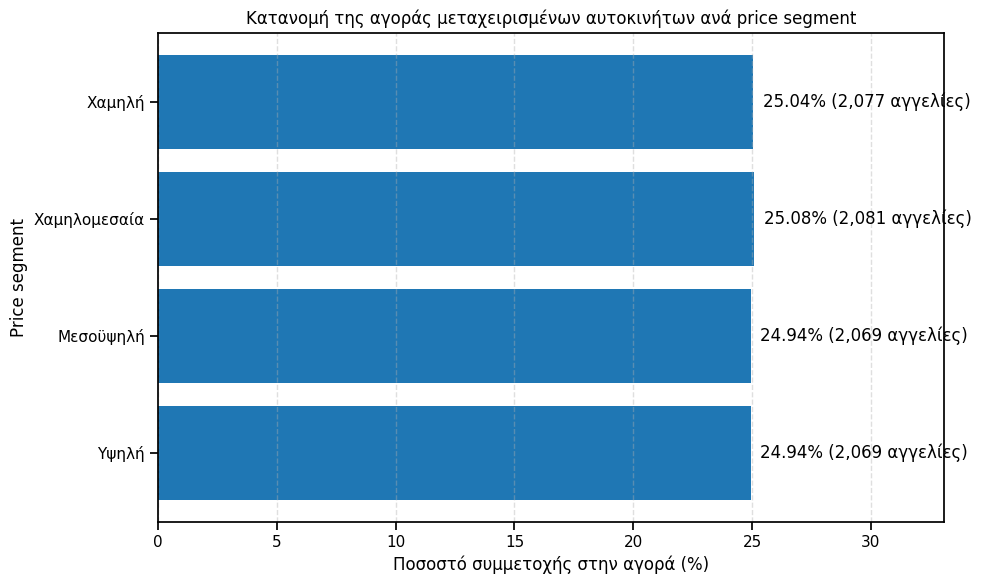

Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_price_segment_share_plot_data.csv


In [11]:
# ============================================
# Notebook 6 - Dashboard-ready plot:
# Κατανομή αγοράς ανά price segment
# ============================================

# ---------------------------------
# 1. Προετοιμασία των δεδομένων για plotting
# ---------------------------------

segment_distribution_plot_df = price_segment_counts_clean.copy()

segment_distribution_plot_df["price_segment"] = pd.Categorical(
    segment_distribution_plot_df["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

segment_distribution_plot_df = (
    segment_distribution_plot_df
    .sort_values("price_segment")
    .reset_index(drop=True)
)

segment_distribution_plot_df["display_share"] = (
    segment_distribution_plot_df["share_pct"]
    .map(lambda x: f"{x:.2f}%")
)

segment_distribution_plot_df["display_count"] = (
    segment_distribution_plot_df["n_observations"]
    .round(0)
    .astype(int)
    .map(lambda x: f"{x:,}")
)

print("Δεδομένα για το γράφημα κατανομής segments:")
display(segment_distribution_plot_df)


# ---------------------------------
# 2. Δημιουργία γραφήματος
# ---------------------------------

plt.figure(figsize=(10, 6))

bars = plt.barh(
    segment_distribution_plot_df["price_segment"],
    segment_distribution_plot_df["share_pct"]
)

plt.xlabel("Ποσοστό συμμετοχής στην αγορά (%)")
plt.ylabel("Price segment")
plt.title("Κατανομή της αγοράς μεταχειρισμένων αυτοκινήτων ανά price segment")

# Ελαφρύ grid στον οριζόντιο άξονα για καλύτερη αναγνωσιμότητα
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Λίγο περιθώριο δεξιά για να χωρέσουν οι ετικέτες
xmax = segment_distribution_plot_df["share_pct"].max()
plt.xlim(0, xmax + 8)

# ---------------------------------
# 3. Προσθήκη labels πάνω στις μπάρες
# ---------------------------------

for bar, share_text, count_text in zip(
    bars,
    segment_distribution_plot_df["display_share"],
    segment_distribution_plot_df["display_count"]
):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2

    plt.text(
        width + 0.4,
        y_pos,
        f"{share_text} ({count_text} αγγελίες)",
        va="center"
    )

# Βάζουμε τη χαμηλή κατηγορία στην κορυφή για πιο φυσική ανάγνωση
plt.gca().invert_yaxis()

save_plot("notebook6_price_segment_share_bar.png")
plt.show()


# ---------------------------------
# 4. Προαιρετικό export των plot data
# ---------------------------------

export_csv(
    segment_distribution_plot_df,
    "notebook6_price_segment_share_plot_data.csv"
)

## Δημιουργία dashboard-ready plot για τη σύνθεση τύπου καυσίμου ανά `price_segment`

Στο παρόν βήμα δημιουργείται ένα stacked bar chart που αποτυπώνει τη σύνθεση του τύπου καυσίμου μέσα σε κάθε κατηγορία τιμής (`price_segment`).

Το συγκεκριμένο γράφημα είναι ιδιαίτερα χρήσιμο για dashboard και παρουσίαση, επειδή επιτρέπει την άμεση σύγκριση της σχετικής συμμετοχής:
- βενζίνης,
- πετρελαίου,
- υβριδικών,
- plug-in hybrid,
- ηλεκτρικών
και λοιπών κατηγοριών καυσίμου
ανάμεσα στα τέσσερα price segments.

Η οπτικοποίηση αυτή βοηθά στην κατανόηση του τρόπου με τον οποίο διαφοροποιείται το τεχνολογικό προφίλ της αγοράς όσο αυξάνεται η τιμή.

Fuel categories:
['Βενζίνη', 'Πετρέλαιο', 'Υβριδικό Βενζίνης', 'Plug-in Hybrid Βενζίνης', 'Ηλεκτρικό', 'Υβριδικό Πετρελαίου', 'Plug-in Hybrid Πετρελαίου', 'LPG / Βενζίνη', 'CNG / Βενζίνη']

Πίνακας ποσοστών για το stacked plot:


fuel_type,Βενζίνη,Πετρέλαιο,Υβριδικό Βενζίνης,Plug-in Hybrid Βενζίνης,Ηλεκτρικό,Υβριδικό Πετρελαίου,Plug-in Hybrid Πετρελαίου,LPG / Βενζίνη,CNG / Βενζίνη
price_segment,,,,,,,,,
Χαμηλή,52.19,27.35,13.24,0.29,4.33,0.14,0.00,1.54,0.91
Χαμηλομεσαία,46.28,19.51,23.74,2.79,4.81,0.67,0.00,1.49,0.72
Μεσοϋψηλή,26.68,15.61,23.25,24.02,8.60,1.30,0.10,0.14,0.29
Υψηλή,17.25,12.37,8.51,29.53,13.73,10.92,7.68,0.00,0.00


Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook6_fuel_type_mix_stacked_bar.png


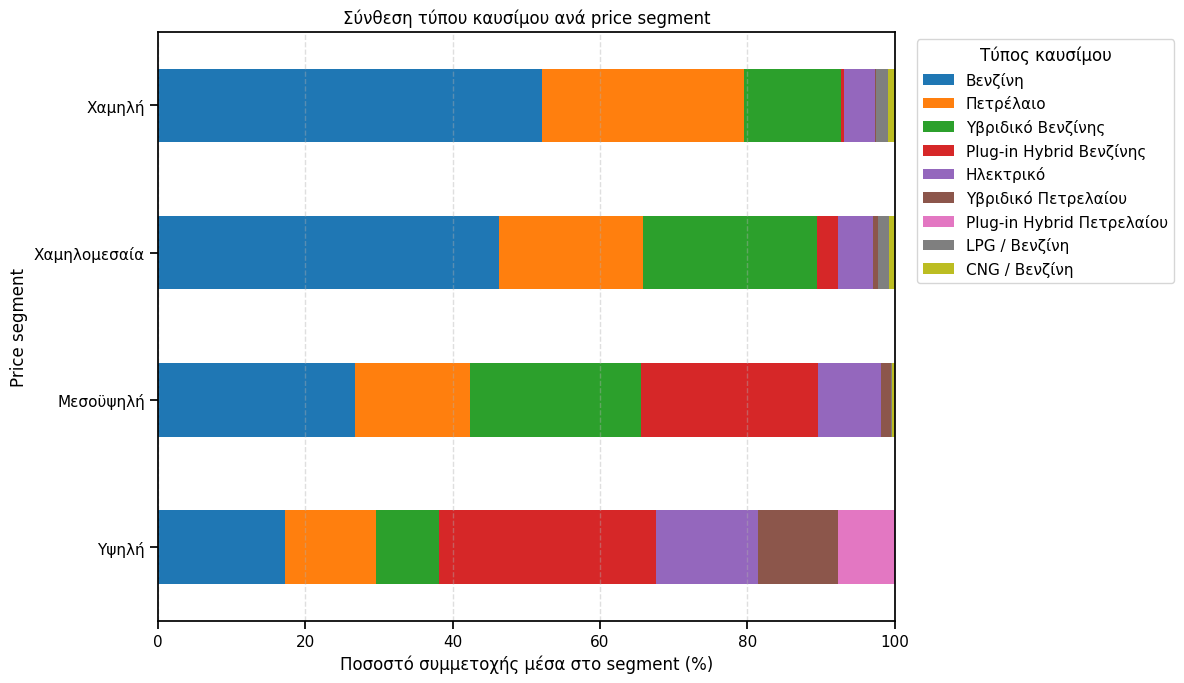

Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_fuel_type_mix_plot_data.csv


In [12]:
# ============================================
# Notebook 6 - Dashboard-ready plot:
# Σύνθεση τύπου καυσίμου ανά price segment
# ============================================

# ---------------------------------
# 1. Προετοιμασία των δεδομένων
# ---------------------------------

fuel_plot_long_df = fuel_dashboard_summary.copy()

fuel_plot_long_df["price_segment"] = pd.Categorical(
    fuel_plot_long_df["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

fuel_plot_long_df = (
    fuel_plot_long_df
    .sort_values(["price_segment", "fuel_type"])
    .reset_index(drop=True)
)

# Κρατάμε τη σειρά εμφάνισης των fuel categories όπως προκύπτει από τα δεδομένα
fuel_type_order = fuel_dashboard_summary["fuel_type"].drop_duplicates().tolist()

fuel_share_pivot = (
    fuel_plot_long_df
    .pivot(index="price_segment", columns="fuel_type", values="share_pct")
    .reindex(canonical_segment_order)
    .fillna(0)
)

fuel_share_pivot = fuel_share_pivot.reindex(columns=fuel_type_order)

print("Fuel categories:")
print(fuel_type_order)

print("\nΠίνακας ποσοστών για το stacked plot:")
display(fuel_share_pivot)


# ---------------------------------
# 2. Δημιουργία stacked horizontal bar chart
# ---------------------------------

ax = fuel_share_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7)
)

ax.set_title("Σύνθεση τύπου καυσίμου ανά price segment")
ax.set_xlabel("Ποσοστό συμμετοχής μέσα στο segment (%)")
ax.set_ylabel("Price segment")
ax.set_xlim(0, 100)
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Βάζουμε τη χαμηλή κατηγορία στην κορυφή
ax.invert_yaxis()

# Legend έξω από το γράφημα για καλύτερη αναγνωσιμότητα
ax.legend(
    title="Τύπος καυσίμου",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

save_plot("notebook6_fuel_type_mix_stacked_bar.png")
plt.show()


# ---------------------------------
# 3. Export των plot data
# ---------------------------------

export_csv(
    fuel_plot_long_df,
    "notebook6_fuel_type_mix_plot_data.csv"
)

## Δημιουργία dashboard-ready plot για τη σύνθεση τύπου κιβωτίου ταχυτήτων ανά `price_segment`

Στο παρόν βήμα δημιουργείται ένα stacked horizontal bar chart που αποτυπώνει τη σύνθεση του τύπου κιβωτίου ταχυτήτων μέσα σε κάθε κατηγορία τιμής (`price_segment`).

Η συγκεκριμένη οπτικοποίηση είναι κατάλληλη για dashboard χρήση, επειδή επιτρέπει τη γρήγορη σύγκριση της σχετικής συμμετοχής:
- αυτόματου κιβωτίου,
- χειροκίνητου κιβωτίου,
- ημιαυτόματου κιβωτίου

ανάμεσα στα τέσσερα price segments.

Με αυτόν τον τρόπο, αναδεικνύεται αν η αγορά μετακινείται προς πιο αυτοματοποιημένες επιλογές όσο αυξάνεται η τιμή.

Transmission categories:
['Αυτόματο', 'Χειροκίνητο', 'Ημιαυτόματο']

Πίνακας ποσοστών για το stacked plot:


transmission_type,Αυτόματο,Χειροκίνητο,Ημιαυτόματο
price_segment,,,
Χαμηλή,17.86,82.09,0.05
Χαμηλομεσαία,50.84,49.11,0.05
Μεσοϋψηλή,86.85,12.76,0.39
Υψηλή,98.16,1.45,0.39


Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook6_transmission_mix_stacked_bar.png


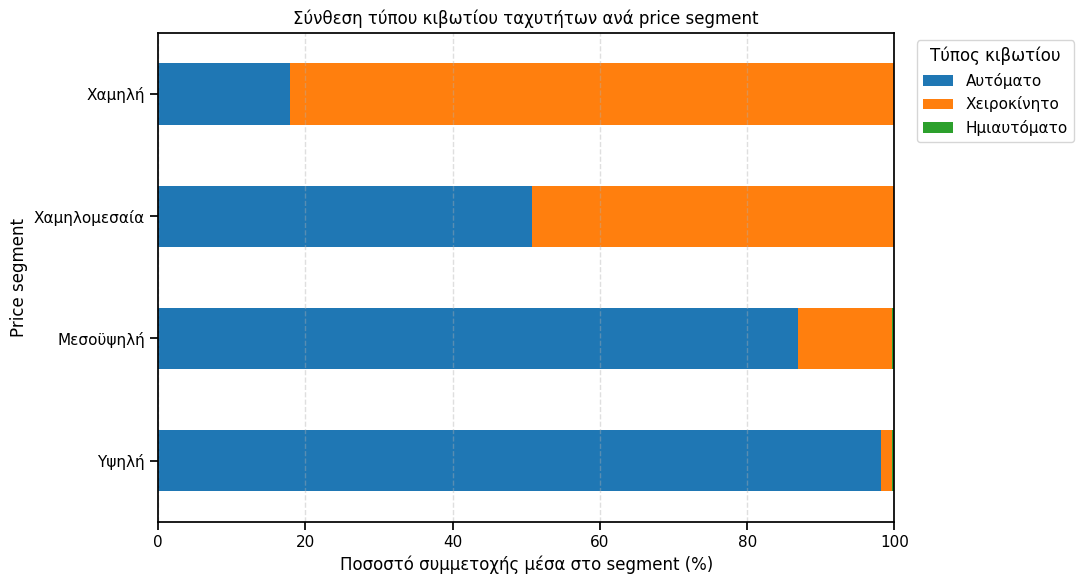

Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_transmission_mix_plot_data.csv


In [13]:
# ============================================
# Notebook 6 - Dashboard-ready plot:
# Σύνθεση κιβωτίου ταχυτήτων ανά price segment
# ============================================

# ---------------------------------
# 1. Προετοιμασία των δεδομένων
# ---------------------------------

transmission_plot_long_df = transmission_dashboard_summary.copy()

transmission_plot_long_df["price_segment"] = pd.Categorical(
    transmission_plot_long_df["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

transmission_plot_long_df = (
    transmission_plot_long_df
    .sort_values(["price_segment", "transmission_type"])
    .reset_index(drop=True)
)

# Κρατάμε τη σειρά εμφάνισης των transmission categories όπως προκύπτει από τα δεδομένα
transmission_type_order = (
    transmission_dashboard_summary["transmission_type"]
    .drop_duplicates()
    .tolist()
)

transmission_share_pivot = (
    transmission_plot_long_df
    .pivot(index="price_segment", columns="transmission_type", values="share_pct")
    .reindex(canonical_segment_order)
    .fillna(0)
)

transmission_share_pivot = transmission_share_pivot.reindex(columns=transmission_type_order)

print("Transmission categories:")
print(transmission_type_order)

print("\nΠίνακας ποσοστών για το stacked plot:")
display(transmission_share_pivot)

# ---------------------------------
# 2. Δημιουργία stacked horizontal bar chart
# ---------------------------------

ax = transmission_share_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 6)
)

ax.set_title("Σύνθεση τύπου κιβωτίου ταχυτήτων ανά price segment")
ax.set_xlabel("Ποσοστό συμμετοχής μέσα στο segment (%)")
ax.set_ylabel("Price segment")
ax.set_xlim(0, 100)
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Βάζουμε τη χαμηλή κατηγορία στην κορυφή
ax.invert_yaxis()

# Το legend μπαίνει έξω από το γράφημα για καθαρότερο layout
ax.legend(
    title="Τύπος κιβωτίου",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

save_plot("notebook6_transmission_mix_stacked_bar.png")
plt.show()

# ---------------------------------
# 3. Προαιρετικό export των plot data
# ---------------------------------

export_csv(
    transmission_plot_long_df,
    "notebook6_transmission_mix_plot_data.csv"
)

## Δημιουργία dashboard-ready plot για τη σύνθεση των top-10 κατασκευαστών ανά `price_segment`

Στο παρόν βήμα δημιουργείται stacked horizontal bar chart που αποτυπώνει τη σύνθεση των σημαντικότερων κατασκευαστών μέσα σε κάθε κατηγορία τιμής (`price_segment`).

Η συγκεκριμένη οπτικοποίηση είναι κατάλληλη για dashboard χρήση, επειδή επιτρέπει:
- τη σύγκριση της σχετικής συμμετοχής των top-10 κατασκευαστών,
- την αναγνώριση μεταβολών στη σύνθεση της αγοράς ανά κατηγορία τιμής,
- την ανάδειξη του αν συγκεκριμένες μάρκες συγκεντρώνονται δυσανάλογα στα υψηλότερα ή χαμηλότερα segments.

Έτσι, το γράφημα λειτουργεί ως συνοπτική απεικόνιση της διάρθρωσης της αγοράς σε επίπεδο brand mix.

Top-10 make categories:
['Mercedes-Benz', 'Peugeot', 'BMW', 'Toyota', 'Opel', 'Volkswagen', 'Citroen', 'Ford', 'Audi', 'Hyundai']

Πίνακας ποσοστών για το stacked plot:


make,Mercedes-Benz,Peugeot,BMW,Toyota,Opel,Volkswagen,Citroen,Ford,Audi,Hyundai
price_segment,,,,,,,,,,
Χαμηλή,0.46,20.14,0.00,10.99,25.06,5.00,22.52,5.69,0.23,9.92
Χαμηλομεσαία,3.24,26.73,3.53,15.13,9.73,13.76,8.14,11.24,3.24,5.26
Μεσοϋψηλή,15.10,16.73,17.20,9.65,2.88,13.31,1.95,5.91,12.22,5.06
Υψηλή,49.58,1.46,26.94,2.54,0.31,2.54,0.08,4.54,11.78,0.23


Το γράφημα αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\plots\notebook6_make_mix_stacked_bar.png


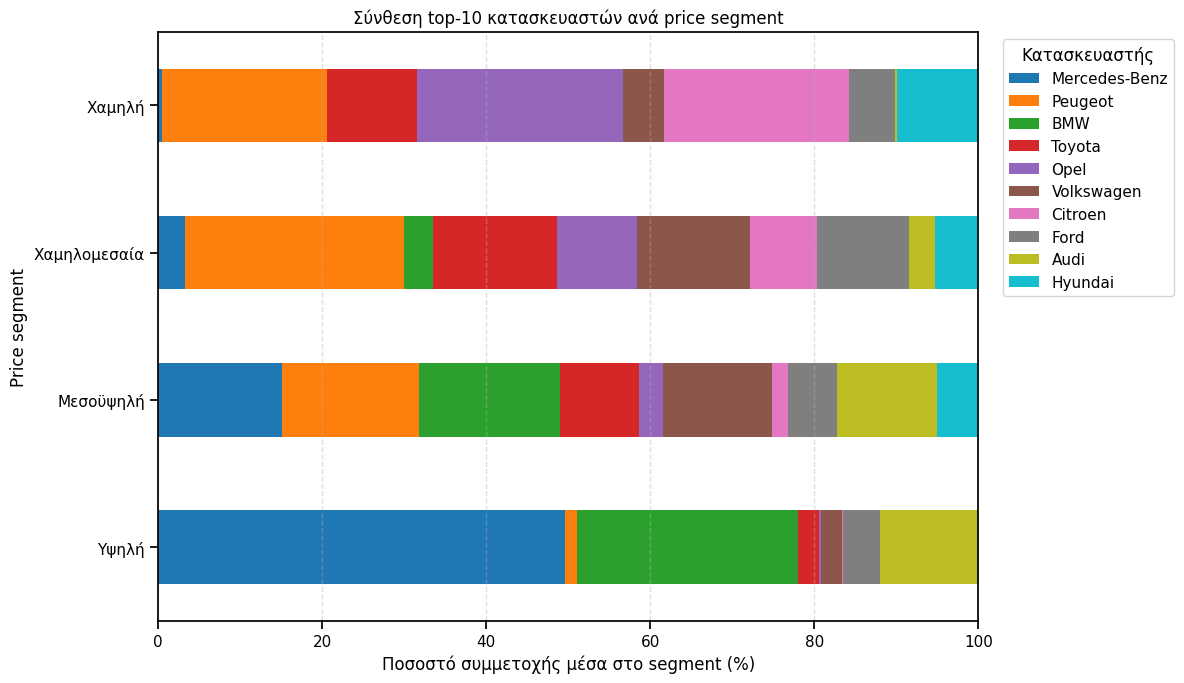

Το αρχείο CSV αποθηκεύτηκε στο: C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\notebook6_make_mix_plot_data.csv


In [14]:
# ============================================
# Notebook 6 - Dashboard-ready plot:
# Σύνθεση top-10 κατασκευαστών ανά price segment
# ============================================

# ---------------------------------
# 1. Προετοιμασία των δεδομένων
# ---------------------------------

make_plot_long_df = make_dashboard_summary.copy()

make_plot_long_df["price_segment"] = pd.Categorical(
    make_plot_long_df["price_segment"],
    categories=canonical_segment_order,
    ordered=True
)

make_plot_long_df = (
    make_plot_long_df
    .sort_values(["price_segment", "make"])
    .reset_index(drop=True)
)

# Κρατάμε τη σειρά των κατασκευαστών όπως προκύπτει από το dashboard summary
make_order = (
    make_dashboard_summary["make"]
    .drop_duplicates()
    .tolist()
)

make_share_pivot = (
    make_plot_long_df
    .pivot(index="price_segment", columns="make", values="share_pct")
    .reindex(canonical_segment_order)
    .fillna(0)
)

make_share_pivot = make_share_pivot.reindex(columns=make_order)

print("Top-10 make categories:")
print(make_order)

print("\nΠίνακας ποσοστών για το stacked plot:")
display(make_share_pivot)

# ---------------------------------
# 2. Δημιουργία stacked horizontal bar chart
# ---------------------------------

ax = make_share_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7)
)

ax.set_title("Σύνθεση top-10 κατασκευαστών ανά price segment")
ax.set_xlabel("Ποσοστό συμμετοχής μέσα στο segment (%)")
ax.set_ylabel("Price segment")
ax.set_xlim(0, 100)
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Η χαμηλή κατηγορία να εμφανίζεται στην κορυφή
ax.invert_yaxis()

# Το legend έξω από το γράφημα για καλύτερη αναγνωσιμότητα
ax.legend(
    title="Κατασκευαστής",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

save_plot("notebook6_make_mix_stacked_bar.png")
plt.show()

# ---------------------------------
# 3. Προαιρετικό export των plot data
# ---------------------------------

export_csv(
    make_plot_long_df,
    "notebook6_make_mix_plot_data.csv"
)

## Τελικός έλεγχος παραδοτέων του Notebook 6

Στο παρόν βήμα πραγματοποιείται συγκεντρωτικός έλεγχος όλων των αρχείων που παρήχθησαν στο Notebook 6, ώστε να επιβεβαιωθεί ότι:

- τα dashboard-ready summary tables έχουν εξαχθεί επιτυχώς,
- τα διορθωμένα αρχεία προέλευσης για downstream χρήση είναι διαθέσιμα,
- τα αρχεία δεδομένων των γραφημάτων έχουν αποθηκευτεί,
- τα τελικά dashboard-ready plots έχουν παραχθεί επιτυχώς.

Ο έλεγχος αυτός λειτουργεί ως τελικό βήμα ποιοτικής διασφάλισης πριν από την οριστικοποίηση του notebook.

In [15]:
# ============================================
# Notebook 6 - Τελικός έλεγχος παραδοτέων
# ============================================

from pathlib import Path

# ---------------------------------
# 1. Ορισμός αναμενόμενων αρχείων
# ---------------------------------

expected_processed_files = [
    "notebook6_top10_make_by_segment_counts_corrected.csv",
    "notebook6_top10_make_by_segment_shares_corrected.csv",
    "notebook6_market_overview_kpi_summary.csv",
    "notebook6_segment_kpi_summary.csv",
    "notebook6_fuel_type_dashboard_summary.csv",
    "notebook6_transmission_dashboard_summary.csv",
    "notebook6_make_dashboard_summary.csv",
    "notebook6_price_segment_share_plot_data.csv",
    "notebook6_fuel_type_mix_plot_data.csv",
    "notebook6_transmission_mix_plot_data.csv",
    "notebook6_make_mix_plot_data.csv"
]

expected_plot_files = [
    "notebook6_price_segment_share_bar.png",
    "notebook6_fuel_type_mix_stacked_bar.png",
    "notebook6_transmission_mix_stacked_bar.png",
    "notebook6_make_mix_stacked_bar.png"
]

# ---------------------------------
# 2. Δημιουργία πίνακα ελέγχου
# ---------------------------------

records = []

for filename in expected_processed_files:
    file_path = PROCESSED_DIR / filename
    records.append({
        "file_name": filename,
        "category": "processed_csv",
        "directory": str(PROCESSED_DIR),
        "exists": file_path.exists(),
        "size_kb": round(file_path.stat().st_size / 1024, 2) if file_path.exists() else None
    })

for filename in expected_plot_files:
    file_path = PLOTS_DIR / filename
    records.append({
        "file_name": filename,
        "category": "plot_png",
        "directory": str(PLOTS_DIR),
        "exists": file_path.exists(),
        "size_kb": round(file_path.stat().st_size / 1024, 2) if file_path.exists() else None
    })

output_check_df = pd.DataFrame(records)

# ---------------------------------
# 3. Συνοπτικά αποτελέσματα ελέγχου
# ---------------------------------

n_expected = len(output_check_df)
n_existing = int(output_check_df["exists"].sum())
all_outputs_ok = bool(output_check_df["exists"].all())

print("Συνολικός αριθμός αναμενόμενων παραδοτέων:", n_expected)
print("Αριθμός αρχείων που βρέθηκαν:", n_existing)
print("Όλα τα παραδοτέα υπάρχουν:", all_outputs_ok)

print("\nΑναλυτικός πίνακας ελέγχου παραδοτέων:")
display(output_check_df)

if not all_outputs_ok:
    print("\nΛείπουν τα παρακάτω αρχεία:")
    display(output_check_df.loc[~output_check_df["exists"], ["file_name", "category", "directory"]])
else:
    print("\nΌλα τα παραδοτέα του Notebook 6 δημιουργήθηκαν επιτυχώς.")

Συνολικός αριθμός αναμενόμενων παραδοτέων: 15
Αριθμός αρχείων που βρέθηκαν: 15
Όλα τα παραδοτέα υπάρχουν: True

Αναλυτικός πίνακας ελέγχου παραδοτέων:


,file_name,category,directory,exists,size_kb
0,notebook6_top10_make_by_segment_counts_correct...,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,0.29
1,notebook6_top10_make_by_segment_shares_correct...,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,0.37
2,notebook6_market_overview_kpi_summary.csv,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,1.74
3,notebook6_segment_kpi_summary.csv,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,10.70
4,notebook6_fuel_type_dashboard_summary.csv,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,5.39
5,notebook6_transmission_dashboard_summary.csv,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,1.95
6,notebook6_make_dashboard_summary.csv,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,5.91
7,notebook6_price_segment_share_plot_data.csv,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,0.24
8,notebook6_fuel_type_mix_plot_data.csv,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,5.39
9,notebook6_transmission_mix_plot_data.csv,processed_csv,C:\Users\athin\Desktop\Car-Market-Analysis-Att...,True,1.95



Όλα τα παραδοτέα του Notebook 6 δημιουργήθηκαν επιτυχώς.
